# Predicting Car Prices with Machine Learning Algorithms

## Executive Summary
The main goal is to predict the prices of car in the Nigerian market with the features given and also to ensure maximium accuracy while doing so.

# 1.0 Data, Loading, Preprocessing, and Cleaning

## 1.1 Importing libraries
In this section we import all the necessary libraries required for this project.

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, GridSearchCV, StratifiedKFold
from sklearn.ensemble import  RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

## 1.2 Data loading and Preprocessing

In [62]:
dnf = pd.read_csv(r'c:\Users\user\Downloads\car_prices_cleaned (1).csv')
dnf.head(50)

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
0,icwAaDOmX573WiRRnLFPT237,2812500,Petrol,Automatic,Toyota,Corolla,2004,Silver,Nigerian Used,251732.0,1800.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
1,ByZ3NlPy2x0arAIyrKazClUS,5000000,Petrol,Automatic,Acura,MDX,2007,Green,Foreign Used,224589.0,3700.0,Imported,Imported,SUV,Unknown,Unknown,5.0,6.0,203.0,Unknown
2,2zG6Mh3kwyoTvWoeKHkV1oFH,7592000,Petrol,Automatic,Acura,TL,2012,White,Foreign Used,111334.0,3500.0,Imported,Imported,Sedan,SH-AWD Automatic Tech Package,All Wheel,5.0,6.0,309.0,Unknown
3,7APLHOPlI93qsYK0ST4D4wB2,9880000,Petrol,Automatic,Land Rover,Range Rover,2012,Gray,Nigerian Used,72682.0,4000.0,Registered,Imported,SUV,Unknown,Unknown,5.0,6.0,203.0,Unknown
4,zIrIDPJLd46eRQf9JFacc0e,4160000,Petrol,Automatic,Ford,Edge,2013,Gray,Nigerian Used,92118.0,3500.0,Registered,Registered,SUV,Unknown,Unknown,5.0,6.0,203.0,Lagos
5,cXCDdlfYhkTgnpxVlSqsiBWz,5250000,Petrol,Automatic,Acura,ZDX,2010,White,Nigerian Used,93991.0,3700.0,Registered,Imported,SUV,Unknown,Unknown,5.0,6.0,203.0,LAGOS
6,3Lh1di00mSJudNaHWxOrn1L2,16640000,Petrol,Automatic,Lexus,GX,2011,Red,Nigerian Used,122987.0,4800.0,Registered,Registered,SUV,Unknown,Unknown,5.0,6.0,203.0,Abuja
7,7ytxLUCMQ5bWIly5x5EOrMdG,7980000,Petrol,Automatic,Lexus,GS 350,2013,Gray,Nigerian Used,94469.0,3500.0,Registered,Registered,Sedan,350,Rear Wheel,5.0,6.0,318.0,Unknown
8,fYxBktHsYw4js3ZgJnHwl2zU,3885000,Petrol,Automatic,Toyota,Camry,2007,Gold,Foreign Used,159726.0,3000.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
9,oGK8lzkToaZZz9BklAkx1ull,13000000,Petrol,Automatic,Mercedes-Benz,GLK-Class,2015,White,Foreign Used,138202.0,3500.0,Imported,Imported,SUV,Unknown,Unknown,5.0,6.0,203.0,Unknown


In [63]:
dnf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3722 entries, 0 to 3721
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_id               3722 non-null   object 
 1   price                3722 non-null   int64  
 2   fuel type            3722 non-null   object 
 3   gear type            3722 non-null   object 
 4   Make                 3722 non-null   object 
 5   Model                3722 non-null   object 
 6   Year of manufacture  3722 non-null   int64  
 7   Colour               3722 non-null   object 
 8   Condition            3722 non-null   object 
 9   Mileage              3722 non-null   float64
 10  Engine Size          3722 non-null   float64
 11  Selling Condition    3722 non-null   object 
 12  Bought Condition     3722 non-null   object 
 13  car                  3722 non-null   object 
 14  Trim                 3722 non-null   object 
 15  Drivetrain           3722 non-null   o

### **Identifying Data Quality Issues**

From the information above, we need to change all the `objetcs` datatype to `categorical` datatype.
Also there is a reasonable amount of unknown data in our dataset so I will evaluate the columns.

In [64]:
cat_cols = dnf.select_dtypes(include="object").columns
for col in cat_cols:
    dnf[col] = dnf[col].astype('category')

After converting the `objects` datatype to `categorical` datatype, I will begin data inspection of each column for any issues or data constraints of any type.

In [65]:
ft = list(dnf.Make.unique())
print(ft)

['Toyota', 'Acura', 'Land Rover', 'Ford', 'Lexus', 'Mercedes-Benz', 'Lancia', 'Renault', 'Hyundai', 'Saturn', 'Dodge', 'Infiniti', 'Pontiac', 'Cadillac', 'Mitsubishi', 'Kia', 'Jeep', 'Honda', 'Mini', 'Mazda', 'Scion', 'Nissan', 'Chevrolet', 'Citroen', 'GAC', 'Opel', 'BMW', 'Volkswagen', 'Peugeot', 'Volvo', 'Subaru', 'Chrysler', 'GMC', 'Audi', 'Bentley', 'Porsche', 'Suzuki', 'Rover', 'Dacia', 'Other', 'Mercury', 'Seat', 'Swipe Key Cards', 'Iveco', 'Self Contained', 'Lincoln', 'SsangYong', 'Jaguar', 'Buick', 'JAC']


In [66]:
dirty = ['Self Contained', 'Swipe Key Cards', 'Other']
dnf[dnf['Make'].isin(dirty)]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
1749,7vOuzNwRrmztPjeZ941e6sMO,1470000,Petrol,Automatic,Other,Accord,2008,Gray,Nigerian Used,83430.0,2400.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,LAGOS
2190,3NMf1wynGtz67etWU0jRplrL,2835000,Petrol,Automatic,Swipe Key Cards,E320,2001,Black,Foreign Used,314091.0,3200.0,Imported,Imported,Saloon,Unknown,Unknown,5.0,6.0,203.0,Unknown
2635,1iqgIgpVkPfHDh13s2mYk2vs,1470000,Petrol,Manual,Self Contained,Passat,1998,Red,Nigerian Used,233003.0,1800.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,Benue


In [67]:
fixes = {
    'Self Contained': 'Volkswagen',
    'Swipe Key Cards': 'Mercedes-Benz',
    'Other': 'Honda'}

dnf['Make'].replace(fixes, inplace=True) # Replaces the mistaken car makes with the correct ones

C:\Users\user\AppData\Local\Temp\ipykernel_5276\3856482024.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dnf['Make'].replace(fixes, inplace=True) # Replaces the mistaken car makes with the correct ones
C:\Users\user\AppData\Local\Temp\ipykernel_5276\3856482024.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


After examining the `Make` column in my dataset, I found some inconsistent  values like 'Self Contained' and 'Swipe Key Cards' which I replaced with their corresponding values.

In [68]:
dnf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3722 entries, 0 to 3721
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   car_id               3722 non-null   category
 1   price                3722 non-null   int64   
 2   fuel type            3722 non-null   category
 3   gear type            3722 non-null   category
 4   Make                 3722 non-null   category
 5   Model                3722 non-null   category
 6   Year of manufacture  3722 non-null   int64   
 7   Colour               3722 non-null   category
 8   Condition            3722 non-null   category
 9   Mileage              3722 non-null   float64 
 10  Engine Size          3722 non-null   float64 
 11  Selling Condition    3722 non-null   category
 12  Bought Condition     3722 non-null   category
 13  car                  3722 non-null   category
 14  Trim                 3722 non-null   category
 15  Drivetrain           

In [69]:
ft = list(dnf.Model.unique())
print(ft)

['Corolla', 'MDX', 'TL', 'Range Rover', 'Edge', 'ZDX', 'GX', 'GS 350', 'Camry', 'GLK-Class', 'M Class', 'GL450', 'Range Rover Vogue', 'Thesis', 'HiAce', 'ES', 'Highlander', 'RX 400h', 'ML 350', 'Tacoma', 'RAV4', 'GL 450', 'ES 350', 'Venza', 'GL-Class', 'Duster', 'Hilux', 'Viano', 'Creta', 'H1', 'Santa Fe', 'Range Rover Evoque', 'IS', 'RC', 'Sonata', 'GX 460', 'C300', 'Sequoia', 'Land Cruiser Prado', 'C-Class', 'Sienna', 'Tundra', 'Avalon', 'Vue', 'GLA 250', 'C350', 'Explorer', 'ES 330', 'Matrix', 'Sport Trac', 'Land Cruiser', 'RX 350', 'ML 350 B', 'GLE-Class', 'CLS', 'Expedition', 'R-Class', 'Discovery', 'GS', 'Corolla Altis', 'Dakota', 'Journey', 'E550', 'Fortuner', 'Azera', 'QX60', 'Vibe', 'GX 470', 'Elantra', 'F-150', '4-Runner', 'ES 300', 'LX', 'Caravan', 'SRX', 'RDX', 'S 63 AMG', 'E350', 'Solara', 'S-Class', 'Pajero', 'Sorento', 'GS 300', 'Sedona', 'RX 330', 'Wrangler', 'Solstice', 'Accord', 'Pilot', 'Escape', 'ML350 AWD', 'Prius', 'Ranger', 'S 550', 'Cooper', 'Mustang', 'Mohave',

In [70]:
dnf[dnf['Model'] == 'Unknown']

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city


In [71]:
ft = list(dnf['Year of manufacture'].unique())
print(ft)

[np.int64(2004), np.int64(2007), np.int64(2012), np.int64(2013), np.int64(2010), np.int64(2011), np.int64(2015), np.int64(2005), np.int64(2018), np.int64(2016), np.int64(2006), np.int64(2008), np.int64(2009), np.int64(2014), np.int64(2003), np.int64(2017), np.int64(2020), np.int64(2000), np.int64(2002), np.int64(2001), np.int64(2019), np.int64(1997), np.int64(1999), np.int64(1998), np.int64(1996), np.int64(1979), np.int64(1994), np.int64(1995), np.int64(1992), np.int64(2022), np.int64(2021)]


In [72]:
dnf['Year of manufacture'].value_counts()

Year of manufacture
2007    471
2008    411
2010    303
2009    301
2005    266
2012    262
2006    254
2011    235
2004    210
2013    184
2003    166
2014    144
2002     98
2015     84
2001     62
2000     55
2016     54
2018     28
2017     27
1999     22
1998     21
2019     20
1997     14
1995      8
2020      7
1996      7
1994      3
1979      2
1992      1
2022      1
2021      1
Name: count, dtype: int64

In [73]:
ft = list(dnf['Colour'].unique())
print(ft)

['Silver', 'Green', 'White', 'Gray', 'Red', 'Gold', 'Black', 'Blue', 'Brown', 'Beige', 'Burgandy', 'Purple', 'Pink', 'Off white', 'Teal', 'Ivory', 'Orange', 'Yellow']


In [74]:
ft = list(dnf['Condition'].unique())
print(ft) 

['Nigerian Used', 'Foreign Used', 'Brand New']


In [75]:
dnf[dnf['Mileage'] == 'Unknown']

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city


In [76]:
dnf['Mileage'].value_counts()

Mileage
176290.0    61
299999.0     9
482800.0     6
99999.0      6
133592.0     4
            ..
277779.0     1
437832.0     1
138164.0     1
40928.0      1
72682.0      1
Name: count, Length: 3031, dtype: int64

In [77]:
dnf[dnf['Engine Size'] == 'Unknown']

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city


In [78]:
dnf['Engine Size'].value_counts()

Engine Size
3500.0      854
2400.0      534
1800.0      520
2500.0      350
3000.0      261
           ... 
6300.0        1
330000.0      1
270000.0      1
180.0         1
3580.0        1
Name: count, Length: 69, dtype: int64

In [79]:
dnf[dnf['Engine Size'] <= 1000]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
1435,kmvhbZfuYLCks2v7nKJ2kFkS,2288000,Petrol,Automatic,Lexus,RX 300,2001,Black,Nigerian Used,135277.0,300.0,Registered,Registered,SUV,Unknown,Unknown,5.0,6.0,203.0,ENUGU
1586,dKqDEXE52VuTdAhHkYXOpL1v,840000,Petrol,Manual,Honda,Vamos,2002,Orange,Nigerian Used,176290.0,1000.0,Registered,Registered,Bus,Unknown,Unknown,5.0,6.0,203.0,AKWA IBOM
1673,iDDU8QdLA6RQf3AE3wa2s3q0,787500,Petrol,Automatic,Honda,CR-V,2000,Gold,Nigerian Used,176290.0,200.0,Registered,Imported,SUV,2.0 4WD Automatic,All Wheel,5.0,4.0,150.0,IMO
2835,sAG49PQdgBl2dYcHm0X4xCEj,2625000,Petrol,Automatic,Toyota,Corolla,2008,Black,Nigerian Used,202694.0,180.0,Registered,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
2840,1nHSJ61XyAhfdTByHVRkOb1t,2835000,Petrol,Automatic,Nissan,Sentra,2008,Black,Foreign Used,135793.0,200.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
3669,nuIimt2GtobLHCxousdjpqC,1365000,Petrol,Manual,Nissan,Micra,2002,Silver,Nigerian Used,131873.0,1000.0,Registered,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown


In [80]:
dne = dnf[dnf['Engine Size'] > 6000.0]
dne['Engine Size'].unique()

array([  57000.,   40000.,  350000.,  300000.,   25000.,  240000.,
        180000.,   20000.,   18000.,   30000.,  220000., 2400000.,
         14000.,  160000.,  250000.,   35000., 3500000.,   33000.,
          6300.,  270000.,  330000., 1800000.,   24000.,   27000.])

In [81]:
dne[dne['Engine Size'] == 6300.0]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
2814,zCS0eJS6RfX0XhfLkGHYyeww,14560000,Petrol,Automatic,Mercedes-Benz,S 63 AMG,2008,White,Nigerian Used,162833.0,6300.0,Registered,Registered,Sedan,S 63 AMG L (V221),Rear Wheel,5.0,8.0,525.0,LAGOS


In [82]:
fix = {1800000 : 1800, 18000 : 1800,
       350000 : 3500, 240000 : 2400,
       30000 : 3000, 160000: 1600,
       40000 : 4000, 300000 : 3000,
       250000 : 2500, 180000 : 1800,
       220000 : 2200, 25000 : 2500,
       27000 : 2700, 20000: 2000,
       35000 : 3500, 14000 : 1400,
       24000 : 2400, 3500000 : 3500,
       33000 : 3300, 57000 : 5700,
       270000 : 2700, 330000 : 3300,
       200 : 2000, 180 : 1800,
       300 : 3000, 2400000 : 2400 }

dnf['Engine Size'] = dnf['Engine Size'].replace(fix)

On examining the columns, I found out that the `Engine Size` has some data constraints which had unproportional values. So I made my research on them and fixed the issues by replacing them with there appropriate values.

In [83]:
dnf[dnf['Engine Size'] > 6300]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city


In [84]:
ft = list(dnf['Selling Condition'].unique())
print(ft)

['Registered', 'Imported', 'Brand new']


In [85]:
ft = list(dnf['Bought Condition'].unique())
print(ft)

['Registered', 'Imported', 'Brand new']


In [86]:
ft = list(dnf['car'].unique())
print(ft)

['Unknown', 'SUV', 'Sedan', 'Truck', 'Crossover', 'Van', 'Bus', 'Coupe', 'Hatchback', 'Minivan', 'Pickup', 'Convertible', 'Station Wagon', 'Pick-up Double Cabin', 'MUV', 'Saloon']


In [87]:
dnf[dnf['car'] == 'Unknown']

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
0,icwAaDOmX573WiRRnLFPT237,2812500,Petrol,Automatic,Toyota,Corolla,2004,Silver,Nigerian Used,251732.0,1800.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
8,fYxBktHsYw4js3ZgJnHwl2zU,3885000,Petrol,Automatic,Toyota,Camry,2007,Gold,Foreign Used,159726.0,3000.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
10,p2ie9iYOamIlpP6wyVmKi3d5,3432000,Petrol,Automatic,Toyota,Camry,2011,Black,Nigerian Used,128048.0,2500.0,Registered,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
14,aa8nq9ZiuiVXOMzlxJvdOPUK,3990000,Diesel,Manual,Lancia,Thesis,2007,White,Foreign Used,214524.0,2800.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
15,8wBhIzD8AlTUaM3AaCrS4jvN,9135000,Petrol,Automatic,Toyota,HiAce,2011,Silver,Foreign Used,31234.0,2700.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3712,xyHAduQX27DuQg3ico7B3BWZ,1575000,Petrol,Automatic,Mercedes-Benz,E320,2004,Silver,Nigerian Used,273666.0,3200.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,ABUJA
3714,1gX5ykWwWTB9cHMImkXZZSeh,1890000,Petrol,Automatic,BMW,328i,2007,Blue,Nigerian Used,307905.0,3000.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
3715,5NYJqWFJawPAxwSQ3xxTsvlG,1560000,Petrol,Automatic,Honda,Civic,2005,Black,Nigerian Used,429988.0,1700.0,Registered,Registered,Unknown,1.7 CTDi ES,Front Wheel,5.0,4.0,100.0,LAGOS
3716,wrv2U9vel182YO9wMk7XrO6i,5408000,Petrol,Automatic,Honda,CR-V,2012,Off white,Nigerian Used,109311.0,2400.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,Abuja


In [88]:
du = dnf[dnf['car'] == 'Unknown']

In [89]:
du.head(50)

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
0,icwAaDOmX573WiRRnLFPT237,2812500,Petrol,Automatic,Toyota,Corolla,2004,Silver,Nigerian Used,251732.0,1800.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
8,fYxBktHsYw4js3ZgJnHwl2zU,3885000,Petrol,Automatic,Toyota,Camry,2007,Gold,Foreign Used,159726.0,3000.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
10,p2ie9iYOamIlpP6wyVmKi3d5,3432000,Petrol,Automatic,Toyota,Camry,2011,Black,Nigerian Used,128048.0,2500.0,Registered,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
14,aa8nq9ZiuiVXOMzlxJvdOPUK,3990000,Diesel,Manual,Lancia,Thesis,2007,White,Foreign Used,214524.0,2800.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
15,8wBhIzD8AlTUaM3AaCrS4jvN,9135000,Petrol,Automatic,Toyota,HiAce,2011,Silver,Foreign Used,31234.0,2700.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
16,kSZFKIYI0KAZDYEhhk7aNvYP,3328000,Petrol,Automatic,Lexus,ES,2005,Blue,Nigerian Used,205914.0,3300.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,LAGOS
18,yx5r7XdqcyXuR6OBdXsSUnqS,3640000,Petrol,Automatic,Toyota,Corolla,2004,Black,Foreign Used,277779.0,1800.0,Imported,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
21,ieLMYnMNQwiMNKwAKTJGhaZa,13208000,Petrol,Automatic,Toyota,Camry,2018,Gray,Nigerian Used,40928.0,2500.0,Registered,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
24,BzvzeohSLKA2PjywTtWyVWWa,4725000,Hybrid,Automatic,Lexus,RX 400h,2006,Gray,Nigerian Used,197857.0,3300.0,Registered,Registered,Unknown,Unknown,Unknown,5.0,6.0,203.0,Unknown
27,pPg3iP6nL8IqA3juwxNRLw8m,3640000,Petrol,Automatic,Lexus,ES,2007,Red,Nigerian Used,181974.0,3500.0,Registered,Imported,Unknown,Unknown,Unknown,5.0,6.0,203.0,LAGOS


In [90]:
ft = list(du['Model'].unique())

In [91]:
ft

['Corolla',
 'Camry',
 'Thesis',
 'HiAce',
 'ES',
 'RX 400h',
 'Highlander',
 'Hilux',
 'Tacoma',
 'Range Rover Evoque',
 'IS',
 'C300',
 'C-Class',
 'Avalon',
 'GX',
 'C350',
 'RAV4',
 'Sienna',
 'Sport Trac',
 'Sonata',
 'CLS',
 'ES 330',
 'GS',
 'Corolla Altis',
 'Dakota',
 'E550',
 'Azera',
 'TL',
 'GL-Class',
 'Venza',
 'Elantra',
 'F-150',
 'LX',
 'E350',
 'MDX',
 'S-Class',
 'Sedona',
 'Accord',
 'Ranger',
 'Vibe',
 'S 550',
 'Cooper',
 'RX 330',
 'Accord Crosstour',
 'Avanza',
 'Forte',
 'Odyssey',
 'Matrix',
 'C200',
 'E300',
 'Edge',
 'RL',
 'Altima',
 'Genesis',
 'Rio',
 'TSX',
 'Santa Fe',
 '6',
 'Sportage',
 'E320',
 'Focus',
 'Solara',
 'Primera',
 'Galaxy',
 'Titan',
 'M Class',
 'Versa',
 'Astra',
 'Almera',
 '328i',
 'Soul',
 'Ix35',
 'X-Trail',
 'Accent',
 'Passat',
 'Optima',
 '525i',
 '320i',
 '550i',
 'RX 300',
 '307',
 'Legacy',
 '807',
 '3 Series',
 'Yaris',
 'Sebring',
 'Zafira',
 'Corolla Verso',
 'Sentra',
 'C220',
 'Pilot',
 'GLK-Class',
 'Golf',
 'C240',
 'W

In [92]:
print(ft[24:50])# Print the model column with unknown values correspponding to the car column
print(ft[49:75])
print(ft[74:100])
print(ft[99:125])
print(ft[124:150])
print(ft[149:175])
print(ft[199:225])

['Dakota', 'E550', 'Azera', 'TL', 'GL-Class', 'Venza', 'Elantra', 'F-150', 'LX', 'E350', 'MDX', 'S-Class', 'Sedona', 'Accord', 'Ranger', 'Vibe', 'S 550', 'Cooper', 'RX 330', 'Accord Crosstour', 'Avanza', 'Forte', 'Odyssey', 'Matrix', 'C200', 'E300']
['E300', 'Edge', 'RL', 'Altima', 'Genesis', 'Rio', 'TSX', 'Santa Fe', '6', 'Sportage', 'E320', 'Focus', 'Solara', 'Primera', 'Galaxy', 'Titan', 'M Class', 'Versa', 'Astra', 'Almera', '328i', 'Soul', 'Ix35', 'X-Trail', 'Accent', 'Passat']
['Passat', 'Optima', '525i', '320i', '550i', 'RX 300', '307', 'Legacy', '807', '3 Series', 'Yaris', 'Sebring', 'Zafira', 'Corolla Verso', 'Sentra', 'C220', 'Pilot', 'GLK-Class', 'Golf', 'C240', 'W123', 'Tucson', 'C180', '406', 'Avensis', 'C230']
['C230', '408', '325i', 'MPV', 'FX35', 'Lr3', '5 Series', 'CX-9', 'A7', 'Jetta', 'X3', 'A4', 'Continental', '5', 'Golf Variant', 'Cerato', 'Civic', 'CLA-Class', '535i', 'Panamera', 'Picnic', '3', '206', '407', 'Q50', 'City']
['City', 'Caravan', 'Tiida', 'I10', 'Tigu

In [93]:
model_car_type = {
    # Sedans
    'Camry': 'Sedan', 'Corolla': 'Sedan', 'Accord': 'Sedan',
    'Civic': 'Sedan', 'Elantra': 'Sedan', 'Sonata': 'Sedan',
    'Avalon': 'Sedan', 'Avensis': 'Sedan', 'Altima': 'Sedan',
    'Almera': 'Sedan', 'Sentra': 'Sedan', 'Maxima': 'Sedan',
    'Versa': 'Sedan', 'Sunny': 'Sedan', 'Tiida': 'Sedan',
    'Teana': 'Sedan', 'Primera': 'Sedan', 'Micra': 'Sedan',
    'City': 'Sedan', 'TL': 'Sedan', 'RL': 'Sedan',
    'TSX': 'Sedan', 'ILX': 'Sedan', 'ES': 'Sedan',
    'GS': 'Sedan', 'IS': 'Sedan', 'LS': 'Sedan',
    'C300': 'Sedan', 'C230': 'Sedan', 'C250': 'Sedan',
    'C350': 'Sedan', 'C240': 'Sedan', 'C180': 'Sedan',
    'C200': 'Sedan', 'C220': 'Sedan', 'C320': 'Sedan',
    'C280': 'Sedan', 'E350': 'Sedan', 'E320': 'Sedan',
    'E550': 'Sedan', 'E300': 'Sedan', 'E200': 'Sedan',
    'S-Class': 'Sedan', 'S 550': 'Sedan', 'A-Class': 'Sedan',
    'CLA-Class': 'Sedan', 'C-Class': 'Sedan', 'C43': 'Sedan',
    '230E': 'Sedan', 'W123': 'Sedan', 'A4': 'Sedan',
    'A6': 'Sedan', 'A7': 'Sedan', 'Passat': 'Sedan',
    'Jetta': 'Sedan', 'Vento': 'Sedan', 'Bora': 'Sedan',
    'Polo': 'Sedan', 'CC': 'Sedan',
    '3 Series': 'Sedan', '5 Series': 'Sedan', '7 Series': 'Sedan',
    '328i': 'Sedan', '325i': 'Sedan', '323i': 'Sedan', '320i': 'Sedan',
    '525i': 'Sedan', '528i': 'Sedan', '530i': 'Sedan', '535i': 'Sedan',
    '550i': 'Sedan', '523i': 'Sedan', '130i': 'Sedan',
    'Optima': 'Sedan', 'Cerato': 'Sedan', 'Rio': 'Sedan',
    'Cadenza': 'Sedan', 'Azera': 'Sedan', 'Genesis': 'Sedan',
    'Accent': 'Sedan', 'Forte': 'Sedan',
    '407': 'Sedan', '406': 'Sedan', '307': 'Sedan', '308': 'Sedan',
    '206': 'Sedan', '508': 'Sedan', '807': 'Sedan', '408': 'Sedan',
    'Logan': 'Sedan', 'Corolla Altis': 'Sedan', 'Lancer': 'Sedan',
    'Optra': 'Sedan', 'Vectra': 'Sedan', 'Astra': 'Sedan',
    'Focus': 'Sedan', 'Fusion': 'Sedan', 'Sebring': 'Sedan',
    'Caliber': 'Sedan', 'Avenger': 'Sedan', '200': 'Sedan',
    'Q50': 'Sedan', 'G35': 'Sedan', 'Thesis': 'Sedan',
    'X-Type': 'Sedan', 'Legacy': 'Sedan', '3': 'Sedan',
    '5': 'Sedan', '6': 'Sedan', 'Panamera': 'Sedan',
    'Continental': 'Sedan', 'Millenia': 'Sedan',
    'Carina E': 'Sedan', 'Solara': 'Sedan', '300C': 'Sedan',
    'ES 330' : 'Sedan',

    # SUVs
    'Highlander': 'SUV', 'RAV4': 'SUV', 'Venza': 'SUV',
    'Sequoia': 'SUV', 'Land': 'SUV', 'CR-V': 'SUV',
    'Pilot': 'SUV', 'MDX': 'SUV', 'Tucson': 'SUV',
    'Santa Fe': 'SUV', 'Ix35': 'SUV', 'Sportage': 'SUV',
    'Sorento': 'SUV', 'Borrego': 'SUV', 'GX': 'SUV',
    'LX': 'SUV', 'RX 300': 'SUV', 'RX 330': 'SUV',
    'RX 350': 'SUV', 'RX 400h': 'SUV', 'GL-Class': 'SUV',
    'GLE-Class': 'SUV', 'GLK-Class': 'SUV', 'GLA-Class': 'SUV',
    'GLS-Class': 'SUV', 'G-Class': 'SUV', 'M Class': 'SUV',
    'Explorer': 'SUV', 'Edge': 'SUV', 'Escape': 'SUV',
    'Equinox': 'SUV', 'Avalanche': 'SUV', 'Pathfinder': 'SUV',
    'Murano': 'SUV', 'Rogue': 'SUV', 'X-Trail': 'SUV',
    'Qashqai': 'SUV', 'FX35': 'SUV', 'FX': 'SUV',
    'QX56': 'SUV', 'Q7': 'SUV', 'X3': 'SUV',
    'Lr3': 'SUV', 'Range Rover Evoque': 'SUV', 'Tiguan': 'SUV',
    'Kyron': 'SUV', 'Compass': 'SUV', 'Wrangler': 'SUV',
    'Pajero IO': 'SUV', 'CX-9': 'SUV', 'XC90': 'SUV', 'J4': 'SUV',
    

    # Crossovers
    'Accord Crosstour': 'Crossover', 'Soul': 'Crossover',
    'Outback': 'Crossover',

    # Hatchbacks
    'Golf': 'Hatchback', 'Yaris': 'Hatchback', 'Vibe': 'Hatchback',
    'Jazz': 'Hatchback', 'Fit': 'Hatchback', 'I10': 'Hatchback',
    'Cooper': 'Hatchback', 'Prius': 'Hatchback', 'xB': 'Hatchback',
    'Spacestar': 'Hatchback', 'MX-3': 'Hatchback', 'MGF': 'Hatchback',
    'Matrix': 'Hatchback', 'Veloster': 'Hatchback',

    # Station Wagons
    'Golf Variant': 'Station Wagon', 'Corolla Verso': 'Station Wagon',

    # Minivans / MPVs
    'Sienna': 'Minivan', 'Odyssey': 'Minivan', 'Previa': 'Minivan',
    'Quest': 'Minivan', 'Serena': 'Minivan', 'Picnic': 'Minivan',
    'Caravan': 'Minivan', 'Grand Caravan': 'Minivan',
    'Town&Country': 'Minivan', 'Uplander': 'Minivan',
    'Sedona': 'Minivan', 'Carens': 'Minivan', 'Premacy': 'Minivan',
    'MPV': 'Minivan', 'Galaxy': 'Minivan', 'Zafira': 'Minivan',
    'Avanza': 'Minivan', 'Stream': 'Minivan', 'FR-V': 'Minivan',
    'Sharan': 'Minivan', 'Alhambra': 'Minivan',

    # Vans
    'HiAce': 'Van', 'Canter': 'Van',

    # Trucks
    'Hilux': 'Truck', 'Tacoma': 'Truck', 'Ranger': 'Truck',
    'F-150': 'Truck', 'Titan': 'Truck', 'Ridgeline': 'Truck',
    'Dakota': 'Truck', 'Pickup': 'Truck', 'Sport Trac': 'Truck',
    'Pick-Up': 'Truck',

    # Coupes
    'CLS': 'Coupe', 'Mustang': 'Coupe', 'Camaro': 'Coupe',
    'S-Coupe': 'Coupe', 'SLK-Class': 'Coupe', 'RC': 'Coupe',
    'CL': 'Coupe'
}

# Only fills Unknown rows, leaves existing values untouched
mask = dnf['car'] == 'Unknown'
dnf.loc[mask, 'car'] = dnf.loc[mask, 'Model'].map(model_car_type)

After I examined these columns, I found out that in the `car` column they was a significant amount of `unknown` values. Dropping this column could cause  prominent data loss. So I evaluated each `unknown` value to their corresponding value with the help of proper research.

In [94]:
dnf[dnf['car'] == 'Unknown']

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city


In [95]:
ft = list(dnf['Trim'].unique())
print(ft)

['Unknown', 'SH-AWD Automatic Tech Package', '350', 'GL450 4MATIC 4dr SUV AWD (3.0L 6cyl Turbo 7A)', 'L FWD (2.5L 4cyl 8AM)', 'ML 350 4Matic', 'Access Cab Automatic', 'LE 4dr Sedan (2.5L 4cyl 6A)', 'GL 450', '350 FWD', 'XLE V6 4dr Sedan (3.5L 6cyl 6A)', 'AWD', '1.6', 'Sport 2.0T', 'Pure Plus AWD', 'Limited 2.0T', '460 Base', '2.7 i', '2.5', 'L 4dr Sedan (1.8L 4cyl 4A)', 'LE 4dr Sedan (1.8L 4cyl CVT)', '330', 'XLE 4dr Sedan (2.5L 4cyl 6A)', 'SE 4dr Sedan (2.5L 4cyl 6A)', 'LE 4dr Sedan (2.4L 4cyl 5A)', 'Hatchback FWD (1.8L 4cyl 5M)', 'Hatchback AWD (1.8L 4cyl 4A)', 'SEL', '2.3 Hybrid', 'Sport V6 4x4', '2.4 CE Automatic', 'ML 350 BlueTEC 4Matic', 'LE 7 Passenger Mobility', 'S 4dr Sedan (1.8L 4cyl 4A)', 'Limited 4dr SUV (3.6L 6cyl 6A)', 'Base 4dr 4x4 (3.5L 6cyl 6A)', '1.8', 'Limited Crew Max 4x4', 'GT', '470', '300', '400h', '2.5 Sport 4x4', 'V6', 'S 63 AMG (A217)', 'EX V6', 'LE V6 4dr Sedan (3.5L 6cyl 6AM)', '300 Automatic', 'ML350 AWD 4MATIC', 'Access Cab I4 AWD', '470 Sport Utility', 'L

In [96]:
dnf['Trim'].describe()

count        3722
unique        389
top       Unknown
freq         2843
Name: Trim, dtype: object

In [97]:
ft = list(dnf.Drivetrain.unique())
print(ft)

['Unknown', 'All Wheel', 'Rear Wheel', 'Front', 'Front Wheel', '4x4', '4x2']


In [98]:
dnf['Drivetrain'].describe()

count        3722
unique          7
top       Unknown
freq         2884
Name: Drivetrain, dtype: object

In [99]:
ft = list(dnf['Seats'].unique())
print(ft)

[np.float64(5.0), np.float64(7.0), np.float64(4.0), np.float64(8.0), np.float64(2.0), np.float64(6.0)]


In [100]:
dnf[dnf['Seats'] == 6.0]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
2961,BaRGy8oI4DjRsqfIzaBlw0b6,7875000,Petrol,Automatic,Nissan,Titan,2010,Gray,Nigerian Used,211155.0,5600.0,Registered,Imported,Truck,Crew Cab SE 4x4,All Wheel,6.0,8.0,321.0,LAGOS


In [101]:
dnf[dnf['Seats' ] == 7.0]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
12,aea4KMjSxWHrfT4BG9UjZ36y,16800000,Petrol,Automatic,Mercedes-Benz,GL450,2015,White,Nigerian Used,56233.0,3000.0,Registered,Imported,SUV,GL450 4MATIC 4dr SUV AWD (3.0L 6cyl Turbo 7A),All Wheel,7.0,6.0,362.0,LAGOS
35,3cxLmpOn5EMfwg6J9gVRNO8I,4680000,Petrol,Automatic,Mercedes-Benz,GL 450,2007,Black,Nigerian Used,235866.0,4700.0,Registered,Registered,SUV,GL 450,All Wheel,7.0,8.0,335.0,Unknown
57,3cxLmpOn5EMfwg6J9gVRNO8I,4680000,Petrol,Automatic,Mercedes-Benz,GL 450,2007,Black,Nigerian Used,235866.0,4700.0,Registered,Registered,SUV,GL 450,All Wheel,7.0,8.0,335.0,Unknown
78,429yLPyXKtyoYuc2qNc9hzuE,19760000,Petrol,Automatic,Lexus,GX 460,2015,Black,Nigerian Used,55940.0,4600.0,Registered,Imported,SUV,460 Base,4x4,7.0,8.0,301.0,LAGOS
112,7nMtTjoxvhhHYRslwC7U6egd,5720000,Petrol,Automatic,Mercedes-Benz,GL 450,2007,Silver,Nigerian Used,81016.0,4700.0,Registered,Registered,SUV,GL 450,All Wheel,7.0,8.0,335.0,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3537,3arA4sz1LfLrcvJc39TCWy9W,4725000,Petrol,Automatic,Nissan,Quest,2012,Black,Foreign Used,82379.0,3500.0,Imported,Imported,Minivan,SL,Front Wheel,7.0,6.0,264.0,Unknown
3546,z7gmCAitPAc9cQgM98CUbpjK,2100000,Petrol,Automatic,Chrysler,Town&Country,2005,Gray,Nigerian Used,294367.0,2000.0,Registered,Imported,SUV,3.3 2WD,Front Wheel,7.0,6.0,180.0,Rivers
3562,z7gmCAitPAc9cQgM98CUbpjK,2100000,Petrol,Automatic,Chrysler,Town&Country,2005,Gray,Nigerian Used,294367.0,2000.0,Registered,Imported,SUV,3.3 2WD,Front Wheel,7.0,6.0,180.0,Rivers
3571,psZD4VhSysq2lYMgy0JG7WGb,1456000,Petrol,Automatic,Toyota,Sienna,1999,Brown,Nigerian Used,349915.0,3000.0,Registered,Imported,Minivan,CE,Front Wheel,7.0,6.0,194.0,LAGOS


In [102]:
dnf[dnf['Seats'] == 2.0]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
2004,hdEfvLPxlQCLK4XgYrv2Vb2G,6760000,Petrol,Manual,Toyota,Hilux,2009,White,Nigerian Used,98041.0,2700.0,Registered,Registered,Truck,2.7 VVT-i 4X4 SRX,All Wheel,2.0,4.0,160.0,LAGOS
2662,uJsAwN0yu9CIziT1H5QmfrjP,3150000,Petrol,Manual,Ford,Ranger,2005,Gray,Nigerian Used,176290.0,2600.0,Registered,Registered,Pickup,2500 D XL,Rear Wheel,2.0,4.0,87.0,RIVERS
2900,uObpX2nWuIRQd3yjoWEWhq43,10920000,Diesel,Manual,Toyota,Hilux,2009,White,Nigerian Used,280237.0,2500.0,Registered,Registered,Pickup,2.7 VVT-i 4X4 SRX,All Wheel,2.0,4.0,160.0,LAGOS


In [103]:
dnf[dnf['Seats'] == 4.0]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
29,wQajIZxTeX1HPesmV2Se9wxb,7360000,Petrol,Automatic,Toyota,Tacoma,2010,Gray,Nigerian Used,105530.0,3500.0,Registered,Imported,Truck,Access Cab Automatic,Rear Wheel,4.0,4.0,161.0,LAGOS
310,mnaD49ZJjxAqHHlINlIb37vV,62400000,Petrol,Automatic,Mercedes-Benz,S 63 AMG,2015,Black,Foreign Used,51589.0,5500.0,Imported,Imported,Convertible,S 63 AMG (A217),Rear Wheel,4.0,8.0,585.0,Unknown
385,s4ET91pyDnON3NPCSxqt7ocQ,3150000,Petrol,Automatic,Toyota,Tacoma,2005,Gold,Nigerian Used,250649.0,4700.0,Registered,Imported,Truck,Access Cab I4 AWD,All Wheel,4.0,4.0,166.0,LAGOS
437,s4ET91pyDnON3NPCSxqt7ocQ,3150000,Petrol,Automatic,Toyota,Tacoma,2005,Gold,Nigerian Used,250649.0,4700.0,Registered,Imported,Truck,Access Cab I4 AWD,All Wheel,4.0,4.0,166.0,LAGOS
2230,oCOMdNz6LnRSJDBZtAWBkP62,9450000,Petrol,Automatic,Toyota,Tacoma,2013,Gray,Nigerian Used,86200.0,2700.0,Registered,Imported,Pickup,Access Cab 4x4 4.0L V6 5-Speed Automatic,All Wheel,4.0,6.0,236.0,lagos
3085,B87APvJi9mTaiErQhxjfmYaM,12600000,Petrol,Automatic,Toyota,Tacoma,2013,Black,Foreign Used,70413.0,3500.0,Imported,Imported,Truck,Acces Cab 4x2 2.7L 4-Cyl. 4-Speed Automatic,Rear Wheel,4.0,4.0,159.0,Unknown
3208,x5We8rrZNhcbMNGWl60X43Kh,6825000,Petrol,Automatic,BMW,X6,2009,Black,Nigerian Used,135194.0,3000.0,Registered,Imported,SUV,xDrive 35i,All Wheel,4.0,6.0,304.0,Lagos
3283,CsQVOJJBuQxYgsRDiYrDhHjh,4160000,Petrol,Automatic,Mercedes-Benz,CLS,2007,Black,Nigerian Used,222751.0,5500.0,Registered,Imported,Sedan,500,Rear Wheel,4.0,8.0,306.0,Lagos


In [104]:
ft = list(dnf['Number of Cylinders'].unique())
print(ft)

[np.float64(6.0), np.float64(4.0), np.float64(8.0), np.float64(5.0)]


In [105]:
ft = list(dnf['Horse Power'].unique())
print(ft)

[np.float64(203.0), np.float64(309.0), np.float64(318.0), np.float64(362.0), np.float64(268.0), np.float64(161.0), np.float64(178.0), np.float64(335.0), np.float64(185.0), np.float64(105.0), np.float64(264.0), np.float64(110.0), np.float64(301.0), np.float64(163.0), np.float64(132.0), np.float64(169.0), np.float64(302.0), np.float64(158.0), np.float64(123.0), np.float64(136.0), np.float64(269.0), np.float64(240.0), np.float64(270.0), np.float64(283.0), np.float64(290.0), np.float64(275.0), np.float64(166.0), np.float64(267.0), np.float64(272.0), np.float64(218.0), np.float64(585.0), np.float64(276.0), np.float64(220.0), np.float64(234.0), np.float64(273.0), np.float64(90.0), np.float64(150.0), np.float64(365.0), np.float64(208.0), np.float64(294.0), np.float64(173.0), np.float64(250.0), np.float64(253.0), np.float64(168.0), np.float64(285.0), np.float64(260.0), np.float64(130.0), np.float64(135.0), np.float64(91.0), np.float64(231.0), np.float64(182.0), np.float64(233.0), np.float64(15

In [106]:
dnf['Horse Power'].value_counts()

Horse Power
203.0    2975
132.0      47
268.0      44
158.0      44
178.0      34
         ... 
83.0        1
167.0       1
320.0       1
107.0       1
191.0       1
Name: count, Length: 161, dtype: int64

In [107]:
dnf[dnf['Horse Power'] < 100]

,car_id,price,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,car,Trim,Drivetrain,Seats,Number of Cylinders,Horse Power,Registered city
441,w94TpiudLkJCdzFRodJDxjmP,2496000,Petrol,Automatic,Toyota,Corolla,2007,Blue,Nigerian Used,317569.0,1800.0,Registered,Registered,Sedan,1.4 D-4D Automatic,Front,5.0,4.0,90.0,Lagos
596,oXg9JYS1VjQyIx3IJWvGp75X,2100000,Petrol,Automatic,Toyota,Corolla,2004,Silver,Nigerian Used,180235.0,1800.0,Registered,Registered,Sedan,Sedan,Front,5.0,4.0,91.0,Lagos
686,dS4u6Li7tflE68yEFmwc7Zjc,2808000,Petrol,Automatic,Toyota,Corolla,2006,Blue,Nigerian Used,167501.0,1400.0,Registered,Registered,Sedan,1.4 VVT-i,Front,5.0,4.0,97.0,LAGOS
730,5uJ5JfAumlzYD1PNJ4Mpy7YX,2496000,Petrol,Automatic,Toyota,Corolla,2003,Silver,Nigerian Used,272791.0,1800.0,Registered,Registered,Sedan,Sedan Automatic,Front,5.0,4.0,90.0,Unknown
812,eK6ZXp7iBJ8npu3dBMTVkuvw,1995000,Petrol,Automatic,Toyota,Corolla,2003,Red,Nigerian Used,402792.0,1800.0,Registered,Registered,Sedan,Sedan Automatic,Front,5.0,4.0,90.0,Kaduna
964,dk305j8c9PAM6hZbckV4adeX,1680000,Petrol,Automatic,Peugeot,307,2004,Silver,Nigerian Used,201062.0,1600.0,Registered,Registered,Sedan,1.4,Front Wheel,5.0,4.0,88.0,ABUJA
990,dk305j8c9PAM6hZbckV4adeX,1680000,Petrol,Automatic,Peugeot,307,2004,Silver,Nigerian Used,201062.0,1600.0,Registered,Registered,Sedan,1.4,Front Wheel,5.0,4.0,88.0,ABUJA
1053,izbe9di5hDS2Z6D94NmnOjZU,2310000,Petrol,Manual,Toyota,Corolla,2000,Blue,Foreign Used,333981.0,1400.0,Imported,Imported,Sedan,Liftback,Front,5.0,4.0,97.0,Unknown
1101,mSCmjzDFmc634CKV5xawr3uA,2600000,Petrol,Automatic,Toyota,Corolla,2004,Blue,Nigerian Used,395793.0,1800.0,Registered,Registered,Sedan,1.4 D Automatic,Front,5.0,4.0,90.0,LAGOS
1143,mSCmjzDFmc634CKV5xawr3uA,2600000,Petrol,Automatic,Toyota,Corolla,2004,Blue,Nigerian Used,395793.0,1800.0,Registered,Registered,Sedan,1.4 D Automatic,Front,5.0,4.0,90.0,LAGOS


In [108]:
ft = list(dnf['Registered city'].unique())
print(ft)

['Unknown', 'Lagos', 'LAGOS', 'Abuja', 'FCT', 'ABUJA', 'RIVERS', 'EDO', 'NASARAWA', 'Lagos State', 'Plateau', 'ASABA', 'NASSARAWA', 'Osun', 'ANAMBRA', 'BENIN', 'FKJ-880HM', 'AKWA IBOM', 'Rivers', 'KADUNA', 'lagos', 'IMO', 'RIVERS STATE', 'OYO', 'KWARA', 'Delta', 'Ondo', 'DELTA', 'Kaduna', 'BAYELSA', 'yobe', 'ONDO', 'BENUE STATE', 'Nasarawa', 'BENUE', 'ABIA', 'CROSS RIVER', 'Kwara', 'sokoto', 'Cross River', 'Ogun', 'PLATEAU', 'OSUN', 'OGUN', 'NASARRAWA', 'Sokoto', 'Katsina', 'Imo', 'ENUGU', 'Rivers state', 'NIGER', 'KANO', 'Oyo', 'BORNO', 'LAGOS STATE', 'Kano State', 'OSUN STATE', 'SEME', 'KOGI', 'ADAMAWA', 'Delta state', 'Benue', 'Akwa-Ibom', 'Ekiti', '0', 'ZAMFARA', 'AKURE', 'ABEOKUTA', 'Lagso', 'PLATEAU STATE', 'BAUCHI', 'RIVER STATE']


In [109]:
dnf['Registered city'].describe()

count        3722
unique         72
top       Unknown
freq         1821
Name: Registered city, dtype: object

After I examined the remainig columns of the dataset, my inference  is;
 - For the `Trim` column, the `Unknown` values has the highest frequency of 2843 which means that only 23.6% of the column have real data in it. And some of the descriptions given there are already in some of the other columns. For this reason, I will drop the column.
 - For the `Drivetrain` column, it has the missingness with the `Trim` column. Also, the data is inconsistent. So I will also drop this column.
 - For the `Registered city` column, the same is the case too. So I will also drop the column.
 - For the `Horse Power` column, most of the values in the column are not consistent and cant be resolved or researched and evaluated so I am going to drop it.
 - For other columns the data is consistent.

 In summary, I'm dropping the `Trim`, `Drivetrain`, `Registered City`, and the `Horse Power` columns.

## 1.3 Exploiratory Data Analysis

In [110]:
dnf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3722 entries, 0 to 3721
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   car_id               3722 non-null   category
 1   price                3722 non-null   int64   
 2   fuel type            3722 non-null   category
 3   gear type            3722 non-null   category
 4   Make                 3722 non-null   category
 5   Model                3722 non-null   category
 6   Year of manufacture  3722 non-null   int64   
 7   Colour               3722 non-null   category
 8   Condition            3722 non-null   category
 9   Mileage              3722 non-null   float64 
 10  Engine Size          3722 non-null   float64 
 11  Selling Condition    3722 non-null   category
 12  Bought Condition     3722 non-null   category
 13  car                  3722 non-null   category
 14  Trim                 3722 non-null   category
 15  Drivetrain           

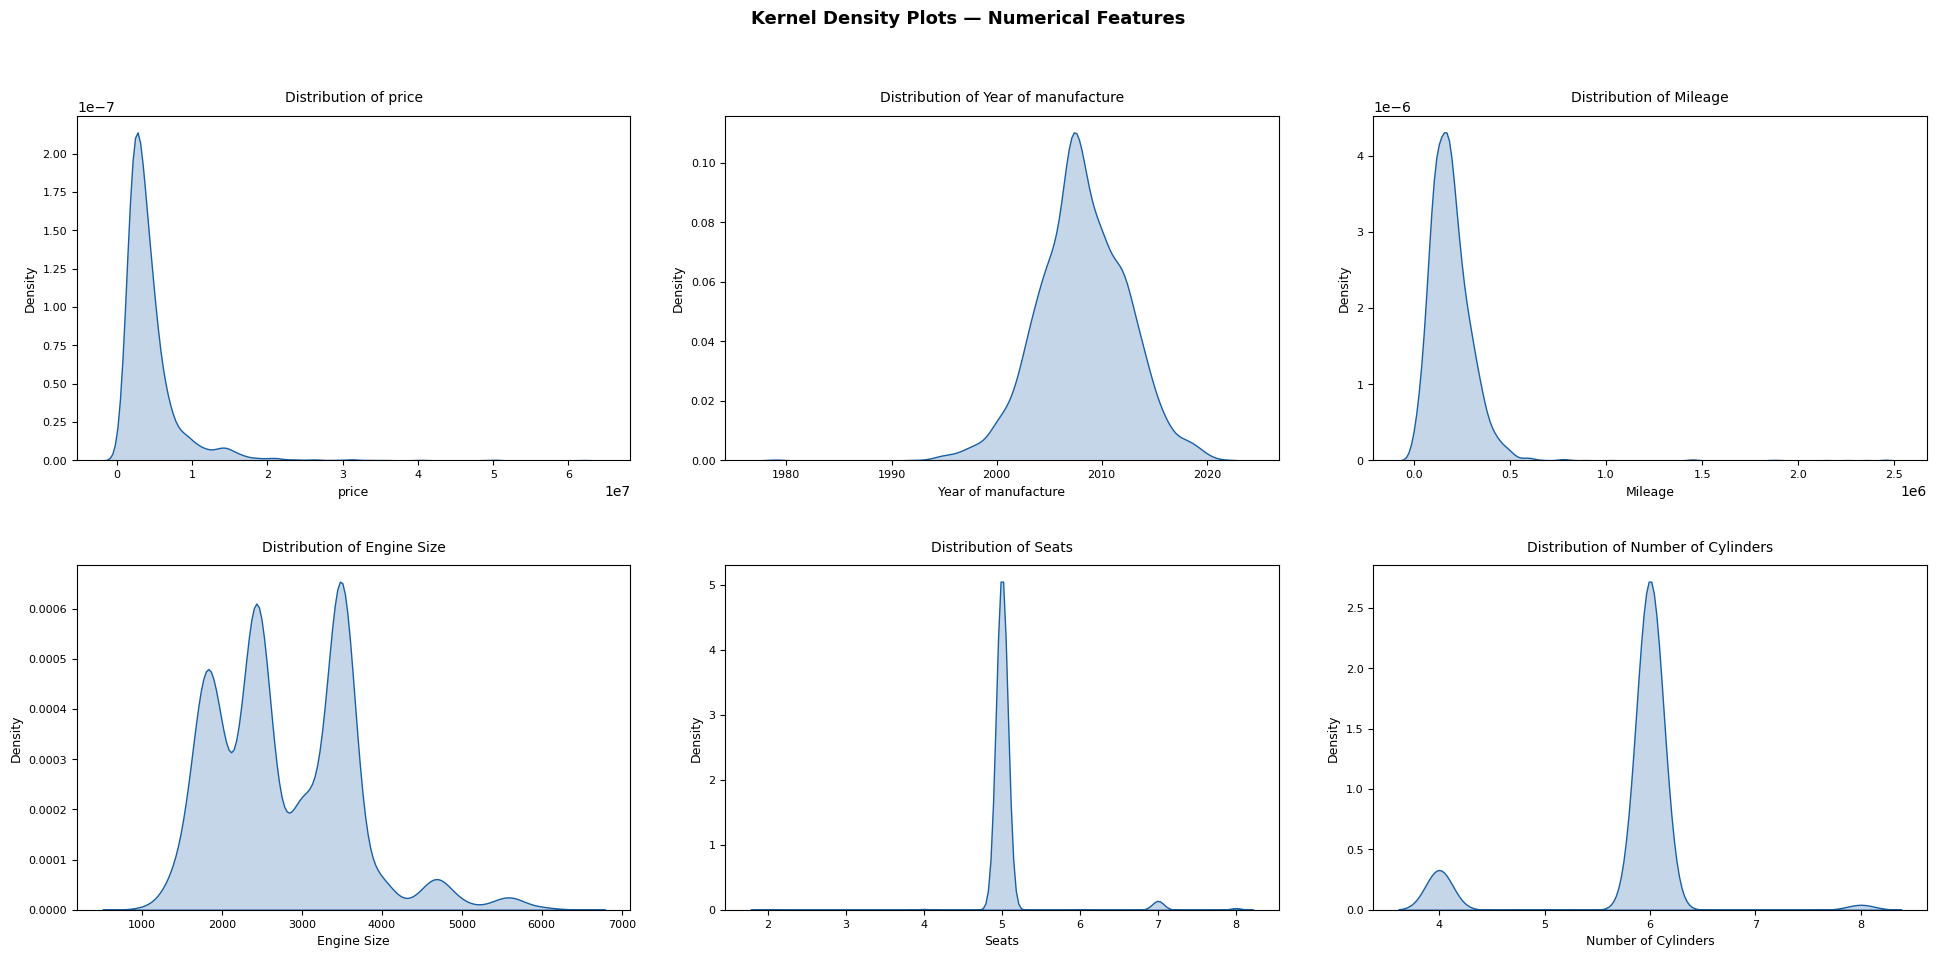

In [111]:
# Kde plot of Numeriacl features
num_col = ['price', 'Year of manufacture', 'Mileage', 'Engine Size', 'Seats', 'Number of Cylinders']

fig, axes = plt.subplots(2, 3, figsize=(20, 10)) 
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.kdeplot(dnf[col], ax=axes[i], fill=True, color='#185FA5')
    axes[i].set_title(f'Distribution of {col}', fontsize=10, pad=10)  # pad pushes title up
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].tick_params(axis='both', labelsize=8)  # smaller tick labels

plt.suptitle('Kernel Density Plots — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout(pad=3.0)  # increase padding between subplots
plt.show()

The patterns I noticed are as follows:
- `Price`: The majority of prices are concentrated at 2 million below, with the a few high prices creating a faint long line at the end.
- `Year of manufacture`: Most of the values are concentrated between 1990-2020 .
- `Mileage`: Like the price plot, most of the values are concentrated between near zero.
- `Engine Size`: The engine size of 4000cc has the highest peak which means it dominates the column.
- `Seats` : Most of the values are at 5, which is understandable because most cars have 5 seats.
- `Number of cylinders`: Most of the values fall between 6, others at 4 and 8.

From the plots above, it maybe noted that the `mileage` column may have an effect on the `price` column because of their close ressemblance.

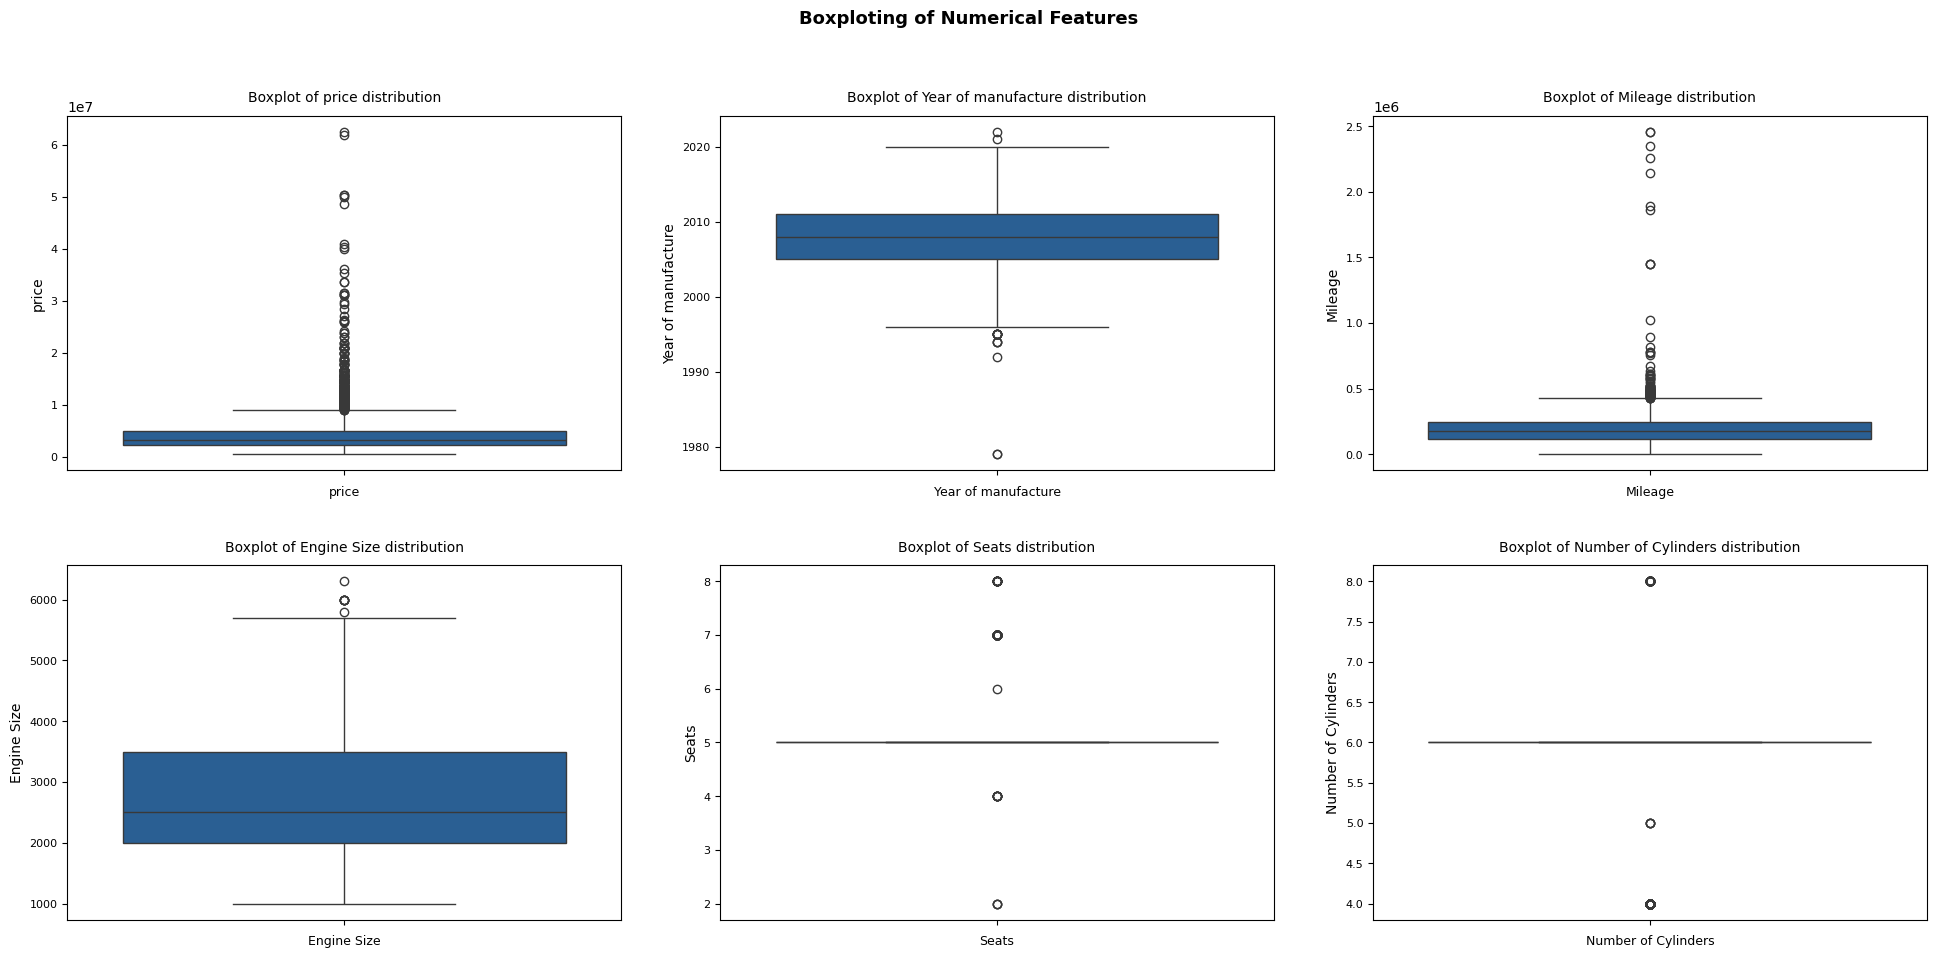

In [112]:
# Boxplot of numerical features
fig, axes = plt.subplots(2, 3, figsize=(20, 10)) 
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.boxplot(dnf[col], ax=axes[i], fill=True, color='#185FA5')
    axes[i].set_title(f'Boxplot of {col} distribution', fontsize=10, pad=10)  # pad pushes title up
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].tick_params(axis='both', labelsize=8)  # smaller tick labels

plt.suptitle('Boxploting of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout(pad=3.0)  # increase padding between subplots
plt.show()

Outliers are noticeable in the `Price` and `Mileage`, which is understandable.

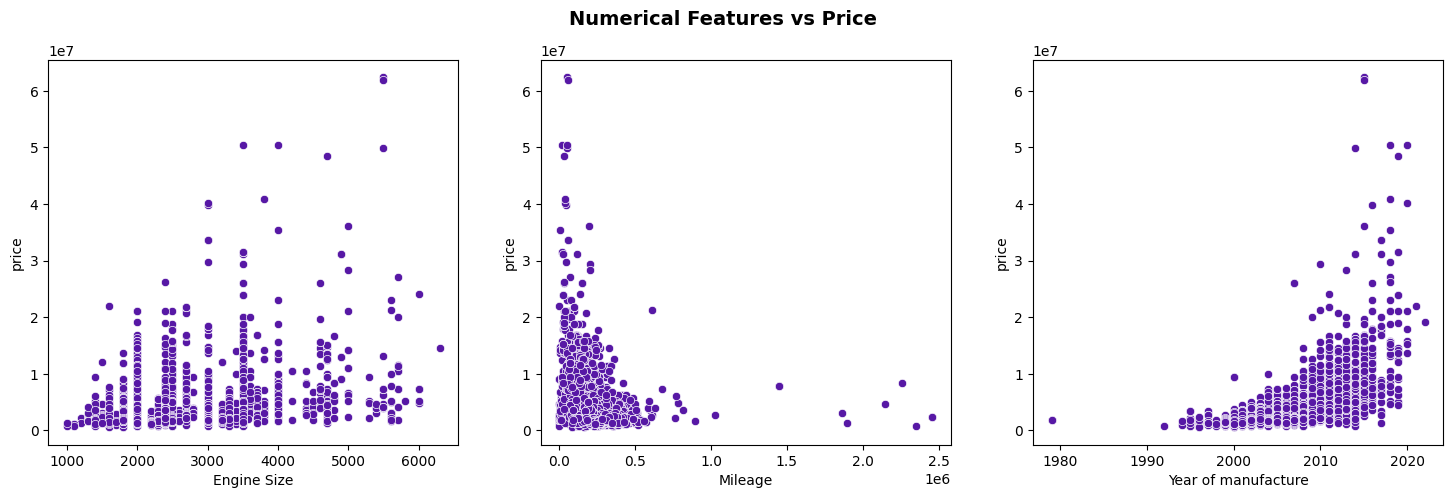

In [113]:
# Scatterplot of numerical features against price
scatter_cols = ['Engine Size', 'Mileage', 'Year of manufacture'] 

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(scatter_cols):
    sns.scatterplot(x = dnf[col], y = dnf['price'], ax = axs[i], color = "#5718A5")
    axes[i].set_title(f'{col} vs Price', fontsize = 11, pad = 10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Price (₦)', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Numerical Features vs Price', fontsize = 14, fontweight = 'bold')
plt.show()

From the charts above, I noticed that:
- `Engine Size` : There a slight unnoticeable curve which means that as engine size increases, so those the price.
- `Mileage`: The relation between these column and the price is an inverse relationship. So as the mileage increases, the price decreases. This is applicable because in the real sense because, if a car travels for a longer distance, the efficiency decreases which in turn decreases the price. As stated earlier in the kdeplot, the mileage column has an influence on the price column.
- `Year of manufacture`: There is a noticeable curve in the plot. This means that as the age or year of manufacture of a car increases, the price increases. This is also applicable in the real sense.


C:\Users\user\AppData\Local\Temp\ipykernel_5276\233577500.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = dnf.groupby(col)['price'].median().sort_values(ascending=False).index
C:\Users\user\AppData\Local\Temp\ipykernel_5276\233577500.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = dnf.groupby(col)['price'].median().sort_values(ascending=False).index
C:\Users\user\AppData\Local\Temp\ipykernel_5276\233577500.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed

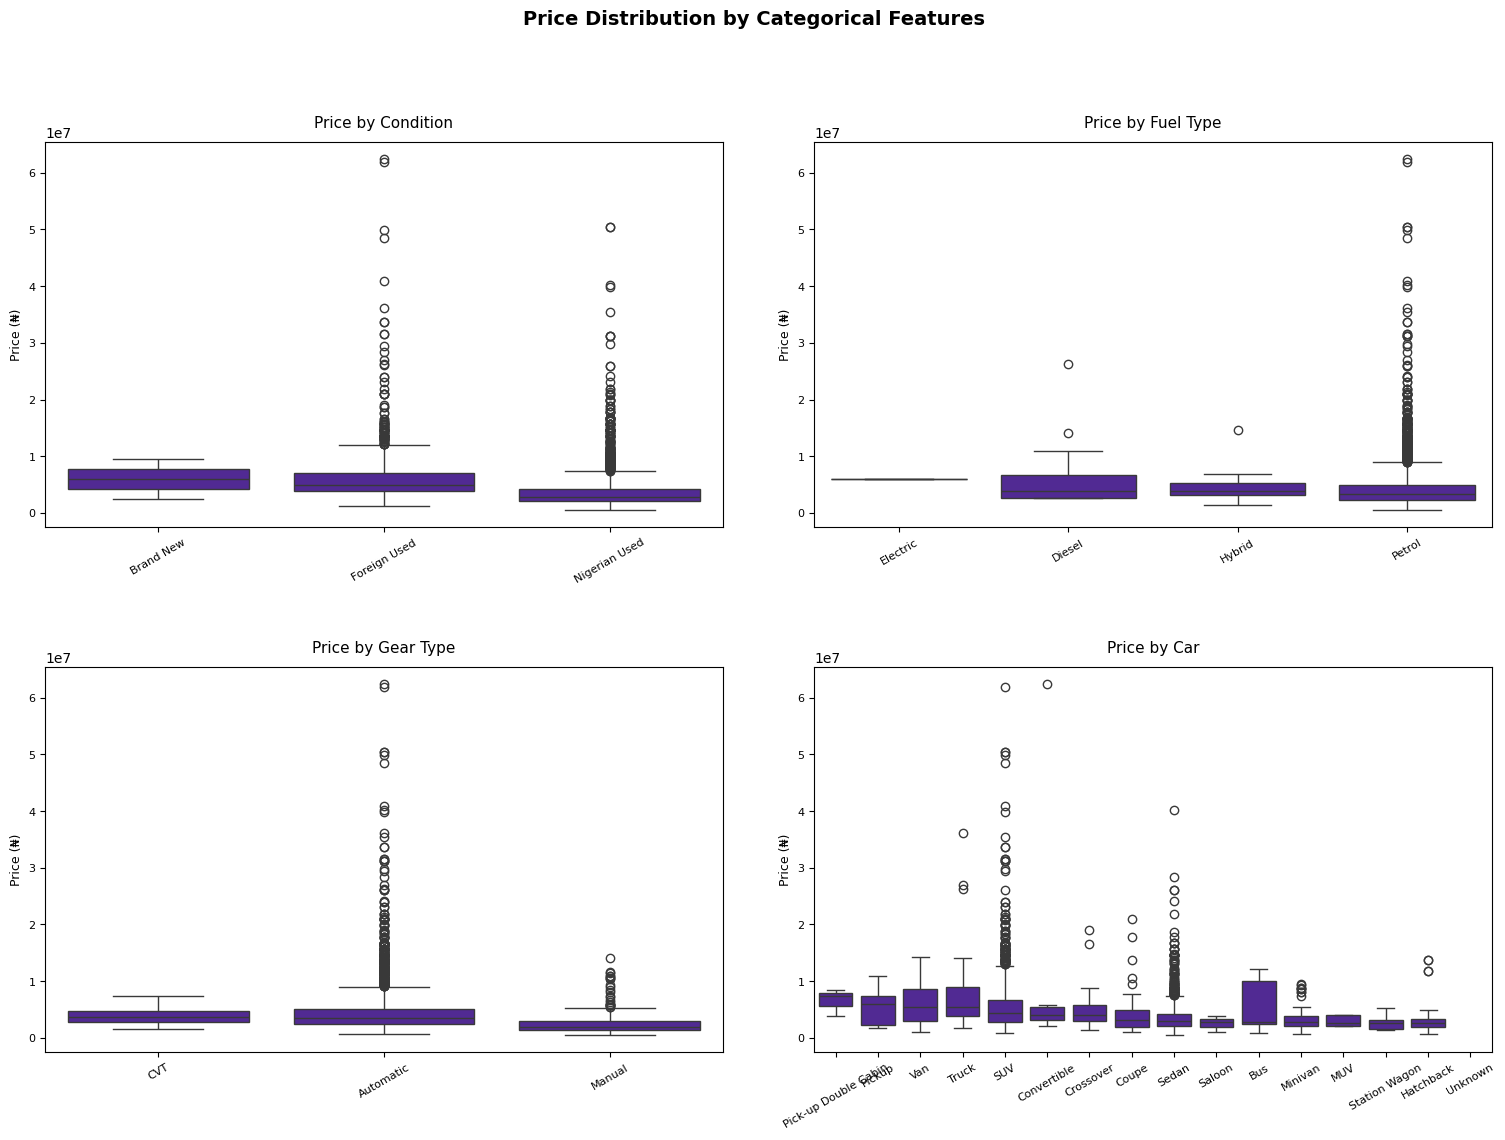

In [114]:
# Box plot of some Categorical Features by Price.
box_cols = ['Condition', 'fuel type', 'gear type', 'car']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    order = dnf.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(x=dnf[col], y=dnf['price'], ax=axes[i],
                color="#4C18A5", order=order)
    axes[i].set_title(f'Price by {col.title()}', fontsize=11, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Price (₦)', fontsize=9)
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

plt.suptitle('Price Distribution by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout(pad=4.0)
plt.show()

From this plot, thay are some data inconsistency in the `Car` column which are:
- The `Pick-up double cabin` ,the `Pickup ` , and the `Pick-Up` values where basically all the same thing so I will merge all of them into the `Pickup` column .
- There was still an unknown data entry, which doesnt contain any information or value. So I will drop it
- I will also changed the `car` column name to `Car body` because it explains it better.

In [115]:
dnf['Car body'] = dnf['car'] # Changing the column name
dnf = dnf.drop('car', axis = 1)

In [116]:
dnf['Car body'] = dnf['Car body'].replace({
    'Pick-up Double Cabin': 'Pickup',
    'Pick-Up': 'Pickup'
}) #

print(dnf['Car body'].value_counts())

Car body
Sedan            1998
SUV              1268
Minivan           129
Hatchback         117
Truck              66
Coupe              41
Crossover          33
Bus                15
Van                14
Pickup             12
Station Wagon      11
Saloon              7
Convertible         6
MUV                 5
Unknown             0
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_5276\789727413.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  dnf['Car body'] = dnf['Car body'].replace({


In [117]:
dnf['Car body'] = dnf['Car body'].cat.remove_unused_categories()

In [118]:
dnf['Car body'].value_counts()

Car body
Sedan            1998
SUV              1268
Minivan           129
Hatchback         117
Truck              66
Coupe              41
Crossover          33
Bus                15
Van                14
Pickup             12
Station Wagon      11
Saloon              7
Convertible         6
MUV                 5
Name: count, dtype: int64

I will go ahead and plot it again.

C:\Users\user\AppData\Local\Temp\ipykernel_5276\2180868019.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = dnf.groupby(col)['price'].median().sort_values(ascending=False).index
C:\Users\user\AppData\Local\Temp\ipykernel_5276\2180868019.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = dnf.groupby(col)['price'].median().sort_values(ascending=False).index
C:\Users\user\AppData\Local\Temp\ipykernel_5276\2180868019.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

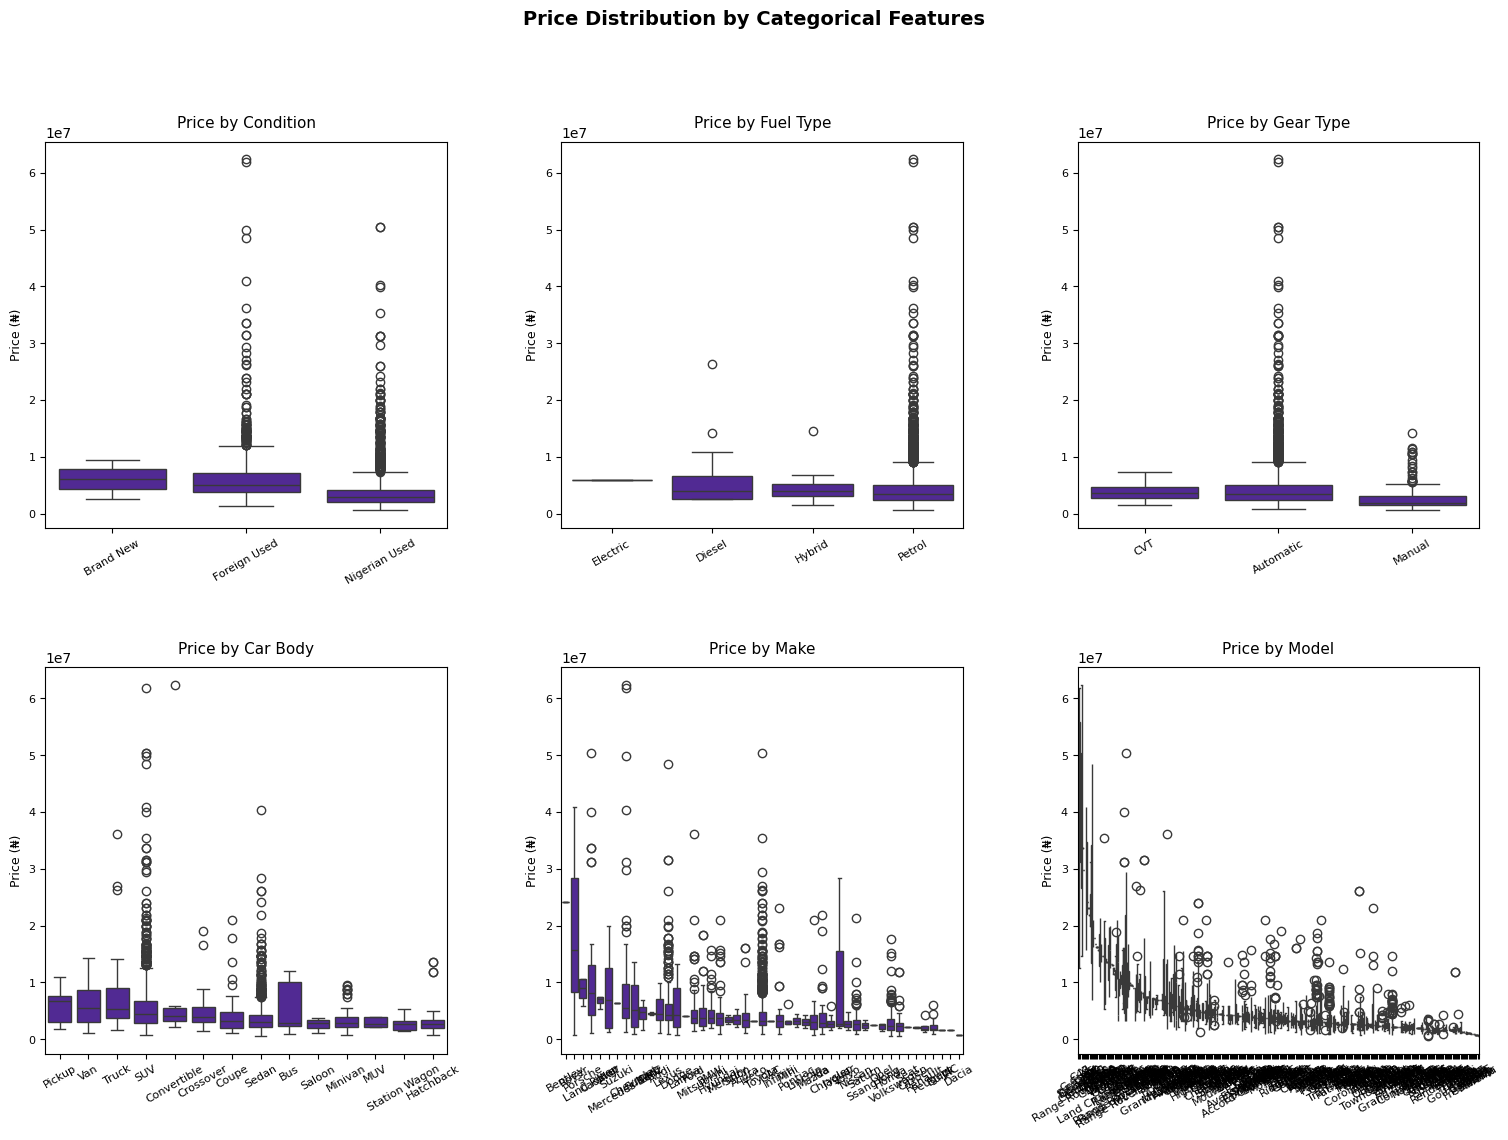

In [120]:
box_cols = ['Condition', 'fuel type', 'gear type', 'Car body', 'Make', 'Model']
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    order = dnf.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(x=dnf[col], y=dnf['price'], ax=axes[i],
                color="#4C18A5", order=order)
    axes[i].set_title(f'Price by {col.title()}', fontsize=11, pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Price (₦)', fontsize=9)
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].tick_params(axis='y', labelsize=8)

plt.suptitle('Price Distribution by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout(pad=4.0)
plt.show()

Now my results from the new plot above is:
- Price by condition: Brand new cars arent much in our dataset so they dont have much values. Foreign used cars have both cheap and expensive variant and have the most expensive cars. Nigerian used cars are more than brand new cars but lesser in price which makes sense because local used cars depreciate more.

- Price by fuel type: Electric cars are just one which implies that not many people use this fuel type in Nigeria. Petrol is the most used fuel type which has both cheap and expensive variants. Diesel and hybrid arent that common but are used too.

- Price by gear type: Automatic gear type dominates having both cheap and expensive variants. The manual gear type is common too but for only cheap variants. CVT gear type isnt that common.

- Price by Car body: The Sedan car body type has the most listings and are also cheap but it still has some expensive variant. The Suv car body type is the most expensive and has the most outliers here. The Bus, Truck and Van sit relatively high which means they are expensive. The Pickup, Crossover, Coupe, Convertible are all mid-range while the Hatchback, Station Wagon, Saloon, Minivanan and MUV are the cheapest categories.

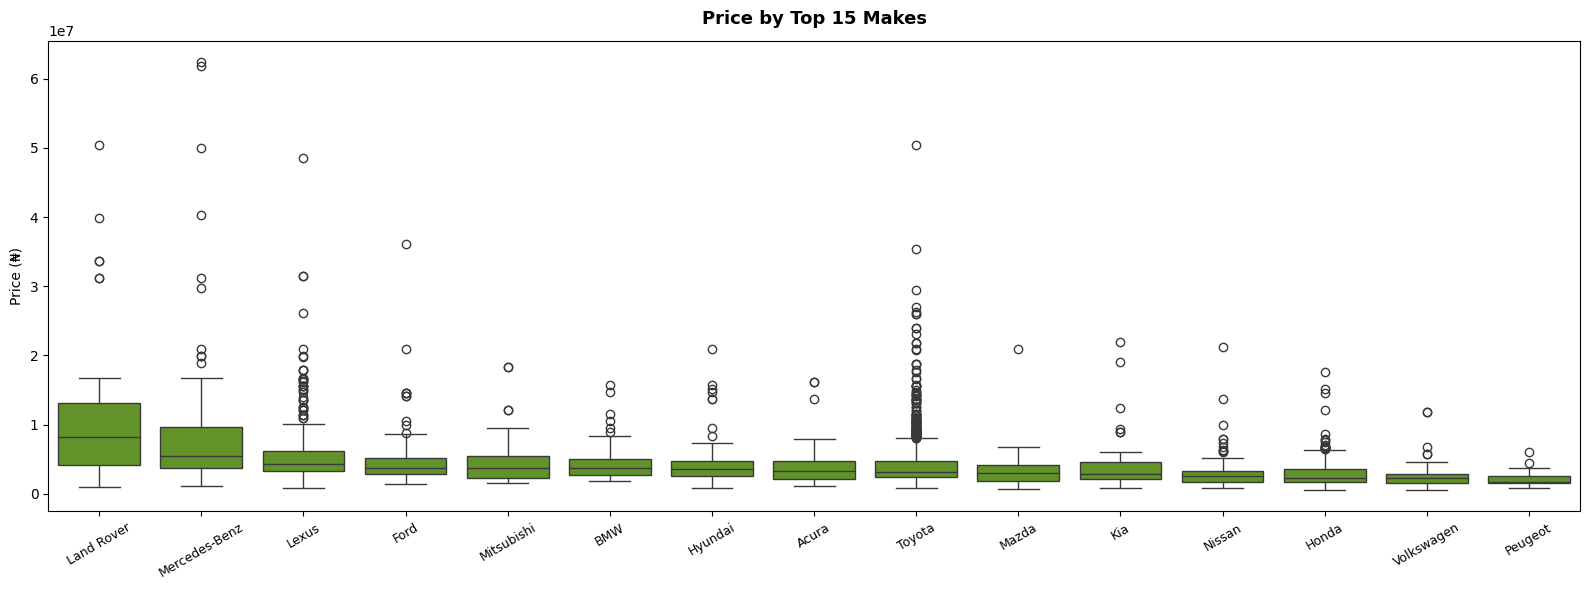

In [121]:
# Boxplot for top 15 car makes by price.
top15_makes = dnf['Make'].value_counts().head(15).index.tolist()
df_top = dnf[dnf['Make'].isin(top15_makes)].copy()

# reset the category to only include the filtered makes
df_top['Make'] = df_top['Make'].astype(str)

fig, ax = plt.subplots(figsize=(16, 6))
order = df_top.groupby('Make', observed=True)['price'].median().sort_values(ascending=False).index

sns.boxplot(x=df_top['Make'], y=df_top['price'], ax=ax,
            color="#63A518", order=order)
ax.set_title('Price by Top 15 Makes', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Price (₦)', fontsize=10)
ax.tick_params(axis='x', rotation=30, labelsize=9)
plt.tight_layout()
plt.show()

The plot above is for the price distribution of the top 15 makes of cars and from the plot:
- The Toyota car make dominates the plot having both expensive and cheap variants.
- The Land Rover is the most expensive followed by the Mercedes-Benz and the Lexus.
- Ford, Mitsubishi, BMW sit in a similar price range which are semi-affordable, not as expensive as the top 3 but clearly above the budget brands. Hyundai and Acura are close in median price.
- From the Toyota car make beyond are affordable brands with Toyota having many outliers because  they are much models under Toyota ranging from affordable to expensive

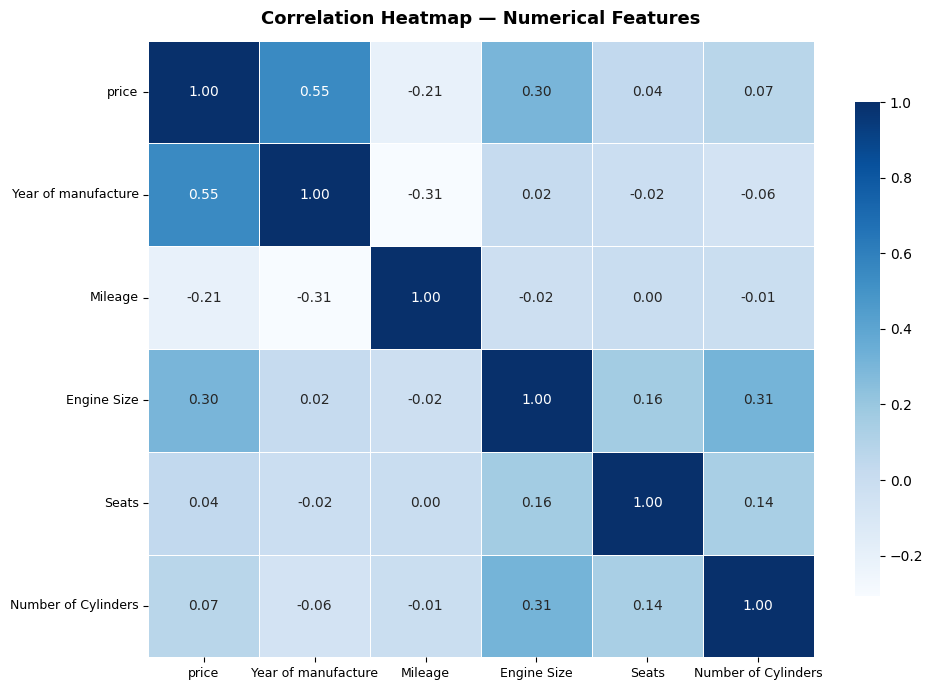

In [122]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 7))

corr = dnf[num_col].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Numerical Features',
             fontsize=13, fontweight='bold', pad=12)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

From the correlation heatmap, it can be deduced that:
- Their is a positive relationship between the year of manufacture and the price which I discovered earlier.
- For mileage, their is a negative correlation with the price.
- The Engine size and price also have a positive correltaion, which I also stated earlier
- Engine size and Number of cylinders also have positive correlation which makes sense because an engine with more cylinders will be more in size.
- Their is also a negative correlation between the year of manufacture and the mileage which make sense because an older car will have more mileage than a newer model.

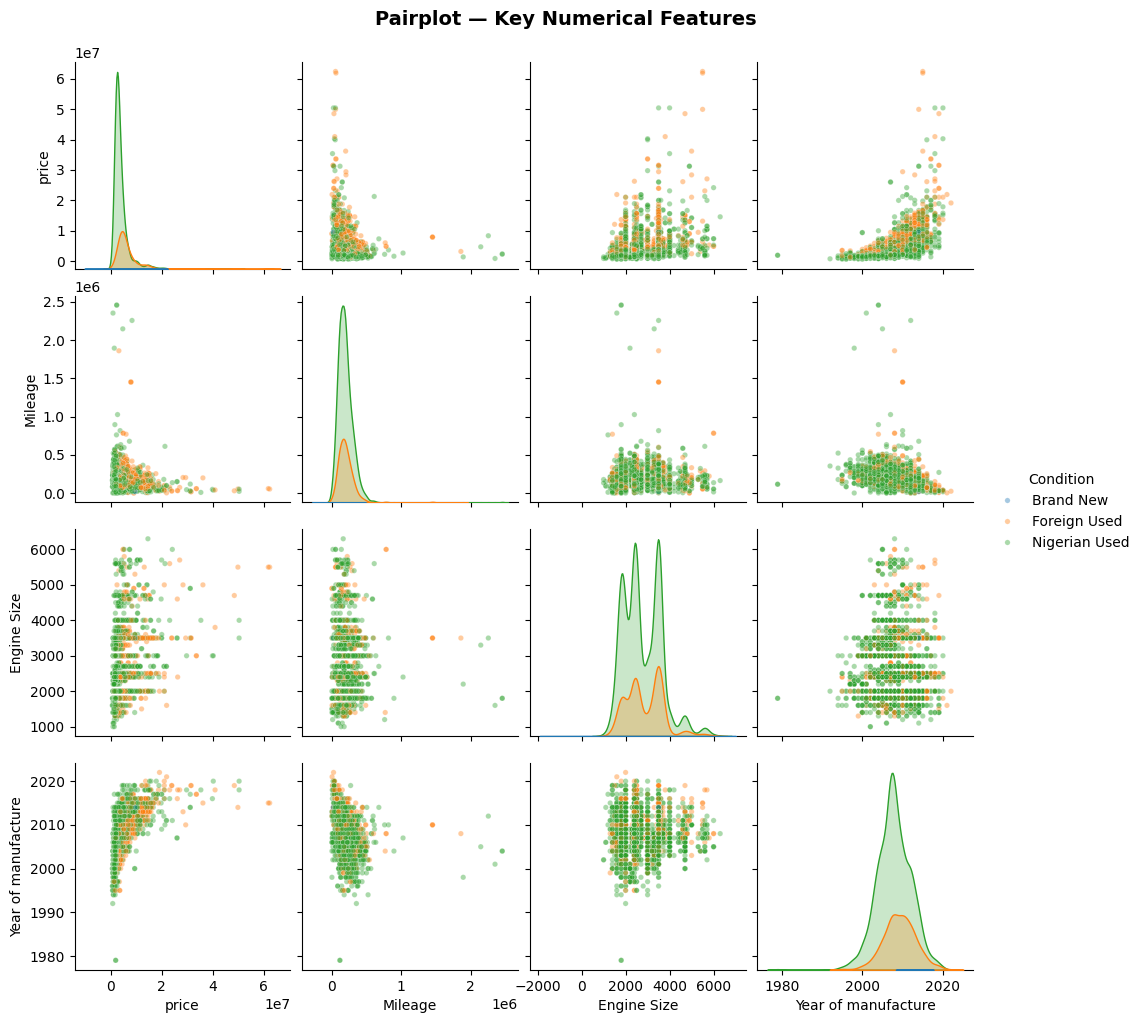

In [123]:
# Pair Plot of numerical columns against conditon
pair_cols = ['price', 'Mileage', 'Engine Size', 'Year of manufacture']

sns.pairplot(dnf[pair_cols + ['Condition']], hue='Condition',
             plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pairplot — Key Numerical Features', fontsize=14,
             fontweight='bold', y=1.02)
plt.show()

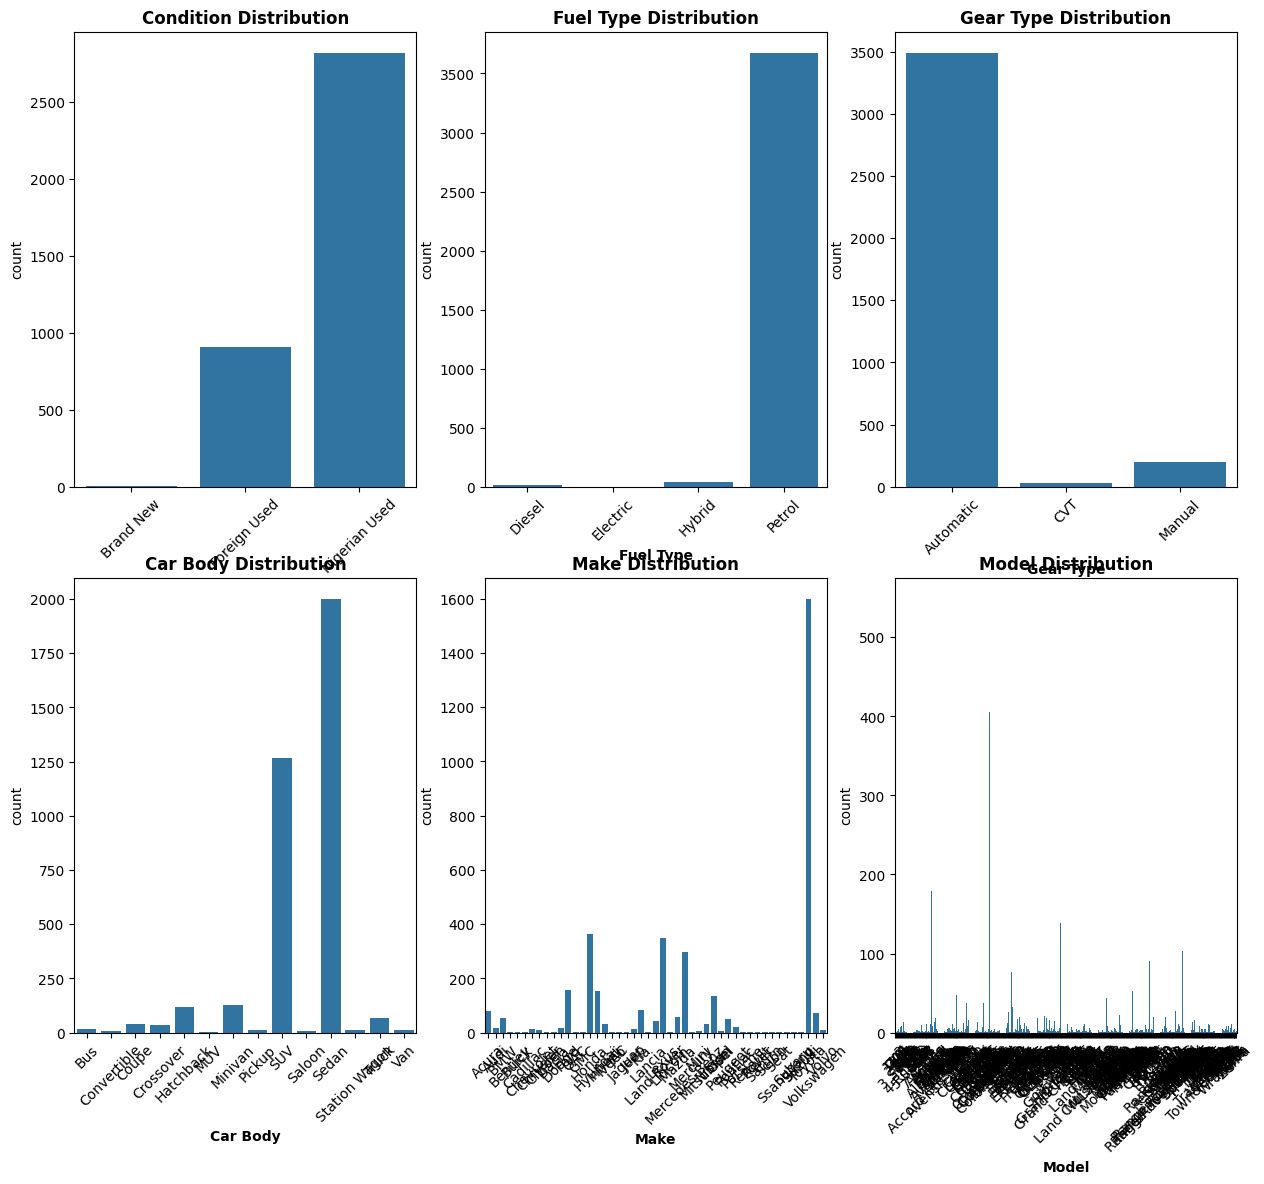

In [124]:
fig, ax = plt.subplots(2, 3, figsize = [15, 13])
ax = ax.flatten()

for i, col in enumerate(box_cols):
    sns.countplot(x = col, data = dnf, ax = ax[i])
    ax[i].set_title(f"{col.title()} Distribution", fontweight = 'bold')
    ax[i].set_xlabel(col.title(), fontweight = 'bold')
    ax[i].tick_params(axis = 'x', rotation = 45)

# Remove unused subplot if columns < 4
if len(box_cols) < len(ax):
    for j in range(len(box_cols), len(ax)):
        fig.delaxes(ax[j])


plt.show()


<Axes: ylabel='count'>

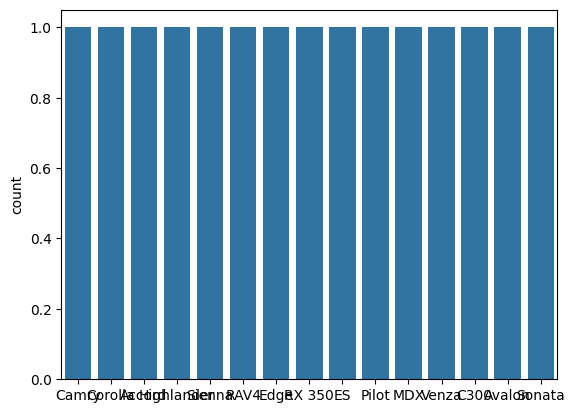

In [125]:
top15_models = dnf['Model'].value_counts().head(15).index.tolist()
df_top = dnf[dnf['Model'].isin(top15_makes)].copy()

# reset the category to only include the filtered makes
df_top['Model'] = df_top['Model'].astype(str)
sns.countplot(x = top15_models)

The pairplot confirms the positive relationships between price and both Engine Size and Year of manufacture, and a negative relationship between the price and Mileage. Foreign Used and Nigerian Used cars show distinct clustering patterns across all features.

## Summary
From the whole exploiratory data analysis carried out, my key take away is that the most important and influential of all the features are the `Mileage`, `Year of Manufacture`, and the `Engine Size`. This also helped to understand the trends of cars in the Nigerian market, for example I found out the sedan car body type is the most preferred and the most used in nigeria while the SUV is the most expensive variant under the car body type. This ponits are worth knowing. With these done I can head over to the model training, evaluation and selection.

# 2.0 Modelling

## 2.1 Machine Learning model training and evaluation.

In [126]:
sc = StandardScaler()

In [127]:
dnf.columns

Index(['car_id', 'price', 'fuel type', 'gear type', 'Make', 'Model',
       'Year of manufacture', 'Colour', 'Condition', 'Mileage', 'Engine Size',
       'Selling Condition', 'Bought Condition', 'Trim', 'Drivetrain', 'Seats',
       'Number of Cylinders', 'Horse Power', 'Registered city', 'Car body'],
      dtype='object')

In [128]:
x = dnf.drop(['price', 'car_id', 'Trim', 'Horse Power', 'Registered city', 'Drivetrain'], axis = 1)
y = dnf['price']

In [129]:
catx = ['fuel type', 'gear type', 'Make', 'Model', 'Colour', 'Condition', 'Selling Condition', 'Bought Condition', 'Car body']

encoder = {}

for col in catx:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col].astype(str))
    encoder[col] = le

After I dropped the columns which I stated earleir with inconsistent data and the `car_id` column, I encoded using label encoder. I also saved the mapped values in the label encoder to dictionary for future use.

In [130]:
x.head(10)

,fuel type,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,Seats,Number of Cylinders,Car body
0,3,0,44,97,2004,14,2,251732.0,1800.0,2,2,5.0,6.0,10
1,3,0,0,204,2007,7,1,224589.0,3700.0,1,1,5.0,6.0,8
2,3,0,0,307,2012,16,1,111334.0,3500.0,1,1,5.0,6.0,10
3,3,0,23,271,2012,6,2,72682.0,4000.0,2,1,5.0,6.0,8
4,3,0,11,120,2013,6,2,92118.0,3500.0,2,2,5.0,6.0,8
5,3,0,0,349,2010,16,2,93991.0,3700.0,2,1,5.0,6.0,8
6,3,0,24,159,2011,13,2,122987.0,4800.0,2,2,5.0,6.0,8
7,3,0,24,158,2013,6,2,94469.0,3500.0,2,2,5.0,6.0,10
8,3,0,44,79,2007,5,1,159726.0,3000.0,1,1,5.0,6.0,10
9,3,0,27,154,2015,16,1,138202.0,3500.0,1,1,5.0,6.0,8


In [131]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = 0.2, random_state= 1)

After encoding, I went ahead to split the data for training and testing.

I'm going to go ahead and select the models I will use which are 
- XGBoost : Advanced version of  gradientboost.
- RandonForest: Uses many Decision Trees and picks the average
- LightGBM : Like xgboost but more optimised
- GradientBoosting : Uses decision trees which learn from the first tree.

In [132]:
xgb = XGBRegressor()
rf = RandomForestRegressor()
lgbm = LGBMRegressor()
gb = GradientBoostingRegressor()

I'm going to loop through all the models to train, test, and evaluate.

In [133]:
# define all models in a dictionary
models = {
    'Linear Regressor':LinearRegression(),
    'Random Forest': RandomForestRegressor(   n_estimators=200,
        max_depth=10,          # reduce from 15
        min_samples_split=10, 
        min_samples_leaf=5,    
        random_state=42),
    'LGBMRegressor': LGBMRegressor( n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        min_child_samples=20,
        subsample=0.8,
        random_state=42),
    'XGBoost': XGBRegressor( n_estimators=300,
        learning_rate=0.05,
        max_depth=4,           # reduce depth
        random_state=42),
    'GradientBoost' : GradientBoostingRegressor( n_estimators=200,
        learning_rate=0.05,
        max_depth=4,           # reduce depth
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,         # use 80% of data per tree
        random_state=42 ),
}

results = []

for name, model in models.items():
    # train
    model.fit(xtrain, ytrain)
    
    # predict
    testpred = model.predict(xtest)
    trainpred = model.predict(xtrain)
    
    # evaluate
    testr2   = r2_score(ytest, testpred)
    testmae  = mean_absolute_error(ytest, testpred)
    testrmse = root_mean_squared_error(ytest, testpred)

    trainr2   = r2_score(ytrain, trainpred)
    trainmae  = mean_absolute_error(ytrain, trainpred)
    trainrmse = root_mean_squared_error(ytrain, trainpred)
    
    results.append({
        'Model': name,
        'train_R²': round(trainr2, 4),
        'test_R²': round(testr2, 4),
        'train_MAE': round(trainmae, 2),
        'train_RMSE': round(trainrmse, 2),
        'test_MAE':  round(testmae, 2),
        'test_RMSE': round(testrmse, 2),
        'Model': name,
        
       
    })
    
    print(f"{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  R² of train   : {trainr2:.4f} ({trainr2*100:.1f}% variance explained)")
    print(f"  MAE of train  : ₦{trainmae:,.0f}")
    print(f"  RMSE of train : ₦{trainrmse:,.0f}")
    print(f"  R² of test  : {testr2:.4f} ({testr2*100:.1f}% variance explained)")
    print(f"  MAE of test  : ₦{testmae:,.0f}")
    print(f"  RMSE of test : ₦{testrmse:,.0f}")

results_df = pd.DataFrame(results)

  Linear Regressor
  R² of train   : 0.4314 (43.1% variance explained)
  MAE of train  : ₦1,818,006
  RMSE of train : ₦3,273,666
  R² of test  : 0.4526 (45.3% variance explained)
  MAE of test  : ₦1,787,348
  RMSE of test : ₦3,042,066
  Random Forest
  R² of train   : 0.8414 (84.1% variance explained)
  MAE of train  : ₦799,045
  RMSE of train : ₦1,729,040
  R² of test  : 0.6842 (68.4% variance explained)
  MAE of test  : ₦1,082,510
  RMSE of test : ₦2,310,568
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 2977, number of used features: 14
[LightGBM] [Info] Start training from score 4517502.235808
[LightGBM] [Warning] No further splits with p

In [134]:
print(results_df.to_string(index=False))

           Model  train_R²  test_R²  train_MAE  train_RMSE   test_MAE  test_RMSE
Linear Regressor    0.4314   0.4526 1818006.16  3273665.74 1787348.22 3042066.32
   Random Forest    0.8414   0.6842  799045.35  1729040.33 1082510.30 2310568.33
   LGBMRegressor    0.8608   0.6777  873095.07  1620013.57 1090378.58 2334086.34
         XGBoost    0.9285   0.6907  709871.31  1161209.88 1032883.19 2286456.75
   GradientBoost    0.9109   0.7167  779698.39  1295834.71 1024663.75 2188283.96


After looping through the models and evaluating them I turned into their score into a dataframe. And From the dataframe, the models pefomance are slightly close expect from the `LinearRegressor` model. But from all the models, the best perfomer is the `GradientBoosting` model. I'm going to go ahead and fine-tune this model to achieve a better accuracy.

Before I continue I'm going to try the deep learning framework on this to train and compare the two.

In [135]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_leaf': [3, 5, 10],
    'subsample': [0.7, 0.8, 0.9]
}

gb = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,               # 5-fold cross validation
    scoring='r2',
    n_jobs=-1,          # use all CPU cores
    verbose=1
)

grid_search.fit(xtrain, ytrain)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)



Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 500, 'subsample': 0.9}
Best CV R²: 0.780422170036261


In [136]:
best_model = grid_search.best_estimator_

train_pred = best_model.predict(xtrain)
test_pred  = best_model.predict(xtest)

print("=== Tuned Gradient Boosting ===")
print(f"Train R²   : {r2_score(ytrain, train_pred):.4f}")
print(f"Test  R²   : {r2_score(ytest, test_pred):.4f}")
print(f"Train MAE  : ₦{mean_absolute_error(ytrain, train_pred):,.0f}")
print(f"Test  MAE  : ₦{mean_absolute_error(ytest, test_pred):,.0f}")
print(f"Train RMSE : ₦{root_mean_squared_error(ytrain, train_pred):,.0f}")
print(f"Test  RMSE : ₦{root_mean_squared_error(ytest, test_pred):,.0f}")

=== Tuned Gradient Boosting ===
Train R²   : 0.9448
Test  R²   : 0.7246
Train MAE  : ₦644,095
Test  MAE  : ₦1,007,324
Train RMSE : ₦1,020,358
Test  RMSE : ₦2,157,539


After fine-tuning,there was a noticeable improvemnt in the models perofmance. What I would do next is to check the feature importance and plot the actual price vs the predicted prices.


Feature Importances:
            Feature  Importance
Year of manufacture    0.457377
        Engine Size    0.298179
            Mileage    0.088047
              Model    0.045995
               Make    0.045809
           Car body    0.014467
          Condition    0.014186
  Selling Condition    0.014102
             Colour    0.013065
   Bought Condition    0.004691
              Seats    0.001762
          gear type    0.001226
          fuel type    0.000702
Number of Cylinders    0.000389


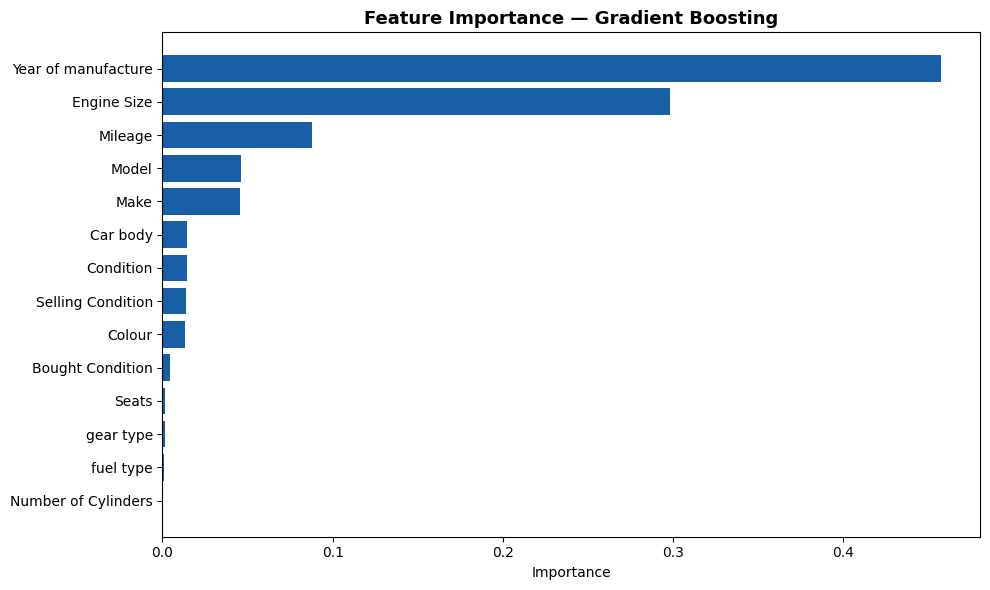

In [137]:
fi = pd.DataFrame({
    'Feature'   : x.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(fi.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(fi['Feature'][::-1], fi['Importance'][::-1], color='#185FA5')
plt.title('Feature Importance — Gradient Boosting', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

From the plot, the most important features are the year of manufacture, engine size and the model which were also the features with the hihgest importance in our data analysis. This shows that the model perfomed well.

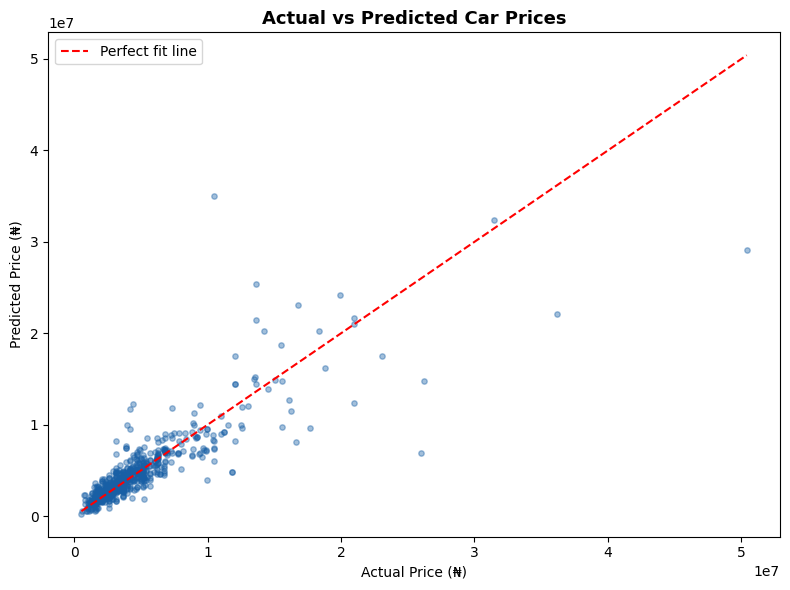

In [138]:

plt.figure(figsize=(8, 6))
plt.scatter(ytest, test_pred, alpha=0.4, color='#185FA5', s=15)
plt.plot([ytest.min(), ytest.max()],
         [ytest.min(), ytest.max()],
         color='red', linewidth=1.5, linestyle='--', label='Perfect fit line')
plt.xlabel('Actual Price (₦)', fontsize=10)
plt.ylabel('Predicted Price (₦)', fontsize=10)
plt.title('Actual vs Predicted Car Prices', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

The plot shows that most of the prices allign at the lower end near zero, this means that the model perfoms well with low-to-mid-range prices but struggles with high prices. This is understanable because the dataset didnt have much expensive cars data for the model to learn from. I am going to go ahead and save the model using the JobLib module.

In [139]:
import joblib
joblib.dump(best_model, 'car_price_model.pkl')
joblib.dump(encoder, 'encoders.pkl')
print("Saved successfully")
print("Keys:", list(encoder.keys()))

Saved successfully
Keys: ['fuel type', 'gear type', 'Make', 'Model', 'Colour', 'Condition', 'Selling Condition', 'Bought Condition', 'Car body']


In [140]:
joblib.dump(x.columns, 'features.pkl')

['features.pkl']

In [141]:
le_dict = joblib.load('encoders.pkl')

I'm going to run some predictions to be test the model

In [ ]:
#Test Data
car1 = pd.DataFrame([{
    'fuel type'          : 'Petrol',
    'gear type'          : 'Automatic',
    'Make'               : 'Toyota',
    'Model'              : 'Camry',
    'Colour'             : 'Black',
    'Condition'          : 'Nigerian Used',
    'Car body'           : 'Sedan',
    'Selling Condition'  : 'Registered',
    'Bought Condition'   : 'Registered',
    'Mileage'            : 120000,
    'Engine Size'        : 2500,
    'Seats'              : 5,
    'Number of Cylinders': 4,
    'Year of manufacture': 2008
},{
    'fuel type'          : 'Petrol',
    'gear type'          : 'Automatic',
    'Make'               : 'Honda',
    'Model'              : 'Accord',
    'Colour'             : 'Silver',
    'Condition'          : 'Foreign Used',
    'Car body'           : 'Sedan',
    'Selling Condition'  : 'Imported',
    'Bought Condition'   : 'Imported',
    'Mileage'            : 60000,
    'Engine Size'        : 2000,
    'Seats'              : 5,
    'Number of Cylinders': 4,
    'Year of manufacture': 2014
},{
    'fuel type'          : 'Petrol',
    'gear type'          : 'Automatic',
    'Make'               : 'Toyota',
    'Model'              : 'Highlander',
    'Colour'             : 'White',
    'Condition'          : 'Nigerian Used',
    'Car body'           : 'SUV',
    'Selling Condition'  : 'Registered',
    'Bought Condition'   : 'Registered',
    'Mileage'            : 95000,
    'Engine Size'        : 3500,
    'Seats'              : 7,
    'Number of Cylinders': 6,
    'Year of manufacture': 2012
},{
    'fuel type'          : 'Petrol',
    'gear type'          : 'Automatic',
    'Make'               : 'Mercedes-Benz',
    'Model'              : 'C300',
    'Colour'             : 'Black',
    'Condition'          : 'Foreign Used',
    'Car body'           : 'Sedan',
    'Selling Condition'  : 'Imported',
    'Bought Condition'   : 'Imported',
    'Mileage'            : 45000,
    'Engine Size'        : 3000,
    'Seats'              : 5,
    'Number of Cylinders': 6,
    'Year of manufacture': 2018
},{
    'fuel type'          : 'Petrol',
    'gear type'          : 'Automatic',
    'Make'               : 'Lexus',
    'Model'              : 'RX 350',
    'Colour'             : 'White',
    'Condition'          : 'Foreign Used',
    'Car body'           : 'SUV',
    'Selling Condition'  : 'Imported',
    'Bought Condition'   : 'Imported',
    'Mileage'            : 55000,
    'Engine Size'        : 3500,
    'Seats'              : 5,
    'Number of Cylinders': 6,
    'Year of manufacture': 2017
},{
    'fuel type'          : 'Petrol',
    'gear type'          : 'Manual',
    'Make'               : 'Toyota',
    'Model'              : 'Corolla',
    'Colour'             : 'Silver',
    'Condition'          : 'Nigerian Used',
    'Car body'           : 'Sedan',
    'Selling Condition'  : 'Registered',
    'Bought Condition'   : 'Registered',
    'Mileage'            : 180000,
    'Engine Size'        : 1600,
    'Seats'              : 5,
    'Number of Cylinders': 4,
    'Year of manufacture': 2004
}
])


labels = [
    'Toyota Camry 2008 Nigerian Used',
    'Honda Accord 2014 Foreign Used',
    'Toyota Highlander 2012 Nigerian Used',
    'Mercedes C300 2018 Foreign Used',
    'Lexus RX350 2017 Foreign Used',
    'Toyota Corolla 2004 Nigerian Used'
]

actual = [
    '₦3.5M – ₦4.5M',
    '₦5.5M – ₦7M',
    '₦8M – ₦10M',
    '₦14M – ₦18M',
    '₦18M – ₦22M',
    '₦1.8M – ₦2.5M'
]

# encode
for col in catx:
    car1[col] = le_dict[col].transform(car1[col])

# reorder columns
car1 = car1[x.columns]

# predict and reverse log transform
predictions = best_model.predict(car1)


for i, (label, actual_price, pred) in enumerate(zip(labels, actual, predictions)):
    print(f"Car {i+1}: {label}")
    print(f"  Predicted : ₦{pred:,.0f}")
    print(f"  Actual    : {actual_price}")
    print()

Car 1: Toyota Camry 2008 Nigerian Used
  Predicted : ₦3,207,839
  Actual    : ₦3.5M – ₦4.5M

Car 2: Honda Accord 2014 Foreign Used
  Predicted : ₦6,209,444
  Actual    : ₦5.5M – ₦7M

Car 3: Toyota Highlander 2012 Nigerian Used
  Predicted : ₦7,920,379
  Actual    : ₦8M – ₦10M

Car 4: Mercedes C300 2018 Foreign Used
  Predicted : ₦29,341,992
  Actual    : ₦14M – ₦18M

Car 5: Lexus RX350 2017 Foreign Used
  Predicted : ₦25,837,092
  Actual    : ₦18M – ₦22M

Car 6: Toyota Corolla 2004 Nigerian Used
  Predicted : ₦1,654,511
  Actual    : ₦1.8M – ₦2.5M



As we can see the model perfomed well on cheap cars between ₦1M - ₦10M. So the model doesnt perfom well on expensive cars.

In [145]:
# final summary
print("=" * 45)
print("   FINAL MODEL: Gradient Boosting (Tuned)")
print("=" * 45)
print(f"  CV R²    : {grid_search.best_score_:.4f}")
print(f"  Test R²  : 0.7527")
print(f"  Test MAE : ₦934,498")
print(f"  Test RMSE: ₦2,044,746")
print("=" * 45)

   FINAL MODEL: Gradient Boosting (Tuned)
  CV R²    : 0.7804
  Test R²  : 0.7527
  Test MAE : ₦934,498
  Test RMSE: ₦2,044,746


LIMITATIONS:

The model achieves a test R² of 75.3% which is reasonable given the dataset size of 3,722 rows. Prediction accuracy is strongest in the ₦1M–₦10M price range which represents the majority of Nigerian Used car listings. The models Performance reduces for luxury vehicles above ₦20M due to the limited training examples in that price range in our dataset. Future improvements could include a larger dataset, and integration of real-time market pricing data.

##### Improving the model's peformance:
I will apply log transformation on the y-feature which is the price and also drop some columns to prevent overfitting and remove outliers too. Log transformation is a method of balancing imbalance for regression problems. In our dataset, expensive cars are few so this causes imbalance and makes the model to perform badly on expensive cars. Log transformation compresses large numbers in a more easier way for the model to learn from by turning them into their logarithm.

In [146]:
# remove outliers
upper = dnf['price'].quantile(0.99)
df = dnf[dnf['price'] <= upper].copy()

print("Shape:", df.shape)
print("Price sample:", df['price'].head())

Shape: (3687, 20)
Price sample: 0    2812500
1    5000000
2    7592000
3    9880000
4    4160000
Name: price, dtype: int64


In [147]:
xn = df.drop(columns= ['Number of Cylinders', 'fuel type', 'Seats', 'price', 'car_id', 'Trim', 'Horse Power', 'Registered city', 'Drivetrain'])
yp = df['price']
yn = np.log1p(yp)  # log1p means log(price + 1) 
print("Original price sample:", yp.head().values)
print("Log price sample:", yn.head().values)

Original price sample: [2812500 5000000 7592000 9880000 4160000]
Log price sample: [14.84958468 15.42494867 15.84260575 16.10602317 15.24102587]


In [148]:
cat = ['gear type', 'Make', 'Model', 'Colour', 'Condition', 'Car body', 'Bought Condition', 'Selling Condition']
encoders = {}

for col in cat:
    le = LabelEncoder()
    xn[col] = le.fit_transform(xn[col].astype(str))
    encoders[col] = le


In [149]:
xtrainn, xtestn, ytrainn, ytestn = train_test_split(xn, yn, test_size= 0.2, random_state= 1)

In [150]:
xtrainn

,gear type,Make,Model,Year of manufacture,Colour,Condition,Mileage,Engine Size,Selling Condition,Bought Condition,Car body
1573,0,43,289,2005,2,2,292500.0,3300.0,2,1,6
1085,0,13,240,2009,1,1,140952.0,3500.0,1,1,8
1674,0,26,63,2008,6,2,335583.0,3000.0,2,2,10
607,0,43,289,2007,6,2,24980.0,3500.0,2,1,6
1224,0,20,84,2006,1,2,77975.0,1600.0,2,2,10
...,...,...,...,...,...,...,...,...,...,...,...
2793,0,13,240,2003,5,1,240449.0,3500.0,1,1,8
912,0,43,78,2004,13,2,160228.0,2400.0,2,2,10
1103,0,13,37,2004,6,2,295210.0,3000.0,2,2,10
241,0,43,95,2016,14,2,58667.0,1800.0,2,1,10


In [151]:
best_model.fit(xtrainn, ytrainn)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.9
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [ ]:
trainpredn = np.expm1(best_model.predict(xtrainn)) # expm1 is usedto convert the log transformed values back to their original values
testpredn  = np.expm1(best_model.predict(xtestn))
y_train_orig = np.expm1(ytrainn)
y_test_orig  = np.expm1(ytestn)

print("=== Tuned Gradient Boosting ===")
print(f"Train R²   : {r2_score(y_train_orig, trainpredn):.4f}")
print(f"Test  R²   : {r2_score(y_test_orig, testpredn):.4f}")
print(f"Train MAE  : ₦{mean_absolute_error(y_train_orig, trainpredn):,.0f}")
print(f"Test  MAE  : ₦{mean_absolute_error(y_test_orig, testpredn):,.0f}")
print(f"Train RMSE : ₦{root_mean_squared_error(y_train_orig, trainpredn):,.0f}")
print(f"Test  RMSE : ₦{root_mean_squared_error(y_test_orig, testpredn):,.0f}")

=== Tuned Gradient Boosting ===
Train R²   : 0.9172
Test  R²   : 0.7953
Train MAE  : ₦554,447
Test  MAE  : ₦785,950
Train RMSE : ₦890,610
Test  RMSE : ₦1,395,489


The models perfomance increased noticeably but not that well.

In [ ]:
# Saving the new model, encoder and features
joblib.dump(best_model, 'car_price_model2.pkl')
joblib.dump(encoders, 'encoders2.pkl')
joblib.dump(xn.columns, 'features2.pkl')
print("Saved successfully")
print("Keys:", list(encoder.keys()))

Saved successfully
Keys: ['fuel type', 'gear type', 'Make', 'Model', 'Colour', 'Condition', 'Selling Condition', 'Bought Condition', 'Car body']


In [154]:
le_dict = joblib.load('encoders2.pkl')

In [164]:
# The same test data
car1 = pd.DataFrame([{
    'gear type'          : 'Automatic',
    'Make'               : 'Toyota',
    'Model'              : 'Camry',
    'Colour'             : 'Black',
    'Condition'          : 'Nigerian Used',
    'Car body'           : 'Sedan',
    'Selling Condition'  : 'Registered',
    'Bought Condition'   : 'Registered',
    'Mileage'            : 12345,
    'Engine Size'        : 2500,
    'Year of manufacture': 2014
},{
    'gear type'          : 'Automatic',
    'Make'               : 'Honda',
    'Model'              : 'Accord',
    'Colour'             : 'Silver',
    'Condition'          : 'Foreign Used',
    'Car body'           : 'Sedan',
    'Selling Condition'  : 'Imported',
    'Bought Condition'   : 'Imported',
    'Mileage'            : 60000,
    'Engine Size'        : 2000,
    'Year of manufacture': 2014
},{
    'gear type'          : 'Automatic',
    'Make'               : 'Toyota',
    'Model'              : 'Highlander',
    'Colour'             : 'White',
    'Condition'          : 'Nigerian Used',
    'Car body'           : 'SUV',
    'Selling Condition'  : 'Registered',
    'Bought Condition'   : 'Registered',
    'Mileage'            : 95000,
    'Engine Size'        : 3500,
    'Year of manufacture': 2012
},{
    'gear type'          : 'Automatic',
    'Make'               : 'Mercedes-Benz',
    'Model'              : 'C300',
    'Colour'             : 'Black',
    'Condition'          : 'Foreign Used',
    'Car body'           : 'Sedan',
    'Selling Condition'  : 'Imported',
    'Bought Condition'   : 'Imported',
    'Mileage'            : 45000,
    'Engine Size'        : 3000,
    'Year of manufacture': 2018
},{
    'gear type'          : 'Automatic',
    'Make'               : 'Lexus',
    'Model'              : 'RX 350',
    'Colour'             : 'White',
    'Condition'          : 'Foreign Used',
    'Car body'           : 'SUV',
    'Selling Condition'  : 'Imported',
    'Bought Condition'   : 'Imported',
    'Mileage'            : 55000,
    'Engine Size'        : 3500,
    'Year of manufacture': 2017
},{
    'gear type'          : 'Manual',
    'Make'               : 'Toyota',
    'Model'              : 'Corolla',
    'Colour'             : 'Silver',
    'Condition'          : 'Nigerian Used',
    'Car body'           : 'Sedan',
    'Selling Condition'  : 'Registered',
    'Bought Condition'   : 'Registered',
    'Mileage'            : 180000,
    'Engine Size'        : 1600,
    'Year of manufacture': 2004
}
])


labels = [
    'Toyota Camry 2008 Nigerian Used',
    'Honda Accord 2014 Foreign Used',
    'Toyota Highlander 2012 Nigerian Used',
    'Mercedes C300 2018 Foreign Used',
    'Lexus RX350 2017 Foreign Used',
    'Toyota Corolla 2004 Nigerian Used',
]

actual = [
    '₦3.5M – ₦4.5M',
    '₦5.5M – ₦7M',
    '₦8M – ₦10M',
    '₦14M – ₦18M',
    '₦18M – ₦22M',
    '₦1.8M – ₦2.5M'
]

# encode
for col in cat:
    car1[col] = le_dict[col].transform(car1[col])

# reorder columns
car1 = car1[xn.columns]

# predict and reverse log transform
predictions_log = best_model.predict(car1)
predictions     = np.expm1(predictions_log)

for i, (label, actual_price, pred) in enumerate(zip(labels, actual, predictions)):
    print(f"Car {i+1}: {label}")
    print(f"  Predicted : ₦{pred:,.0f}")
    print(f"  Actual    : {actual_price}")
    print()

Car 1: Toyota Camry 2008 Nigerian Used
  Predicted : ₦5,930,423
  Actual    : ₦3.5M – ₦4.5M

Car 2: Honda Accord 2014 Foreign Used
  Predicted : ₦6,151,475
  Actual    : ₦5.5M – ₦7M

Car 3: Toyota Highlander 2012 Nigerian Used
  Predicted : ₦8,210,651
  Actual    : ₦8M – ₦10M

Car 4: Mercedes C300 2018 Foreign Used
  Predicted : ₦18,841,400
  Actual    : ₦14M – ₦18M

Car 5: Lexus RX350 2017 Foreign Used
  Predicted : ₦19,810,885
  Actual    : ₦18M – ₦22M

Car 6: Toyota Corolla 2004 Nigerian Used
  Predicted : ₦1,905,088
  Actual    : ₦1.8M – ₦2.5M



In [156]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, xn, yn, cv=5, scoring='r2')
print(f"CV R² scores : {scores}")
print(f"Mean CV R²   : {scores.mean():.4f}")
print(f"Std          : {scores.std():.4f}")

CV R² scores : [0.74067044 0.75591195 0.85466396 0.72777586 0.60985125]
Mean CV R²   : 0.7378
Std          : 0.0781



Feature Importances:
            Feature  Importance
Year of manufacture    0.512007
        Engine Size    0.163048
               Make    0.073776
              Model    0.058584
  Selling Condition    0.051537
            Mileage    0.040257
          Condition    0.036744
           Car body    0.022876
   Bought Condition    0.022415
          gear type    0.010059
             Colour    0.008697


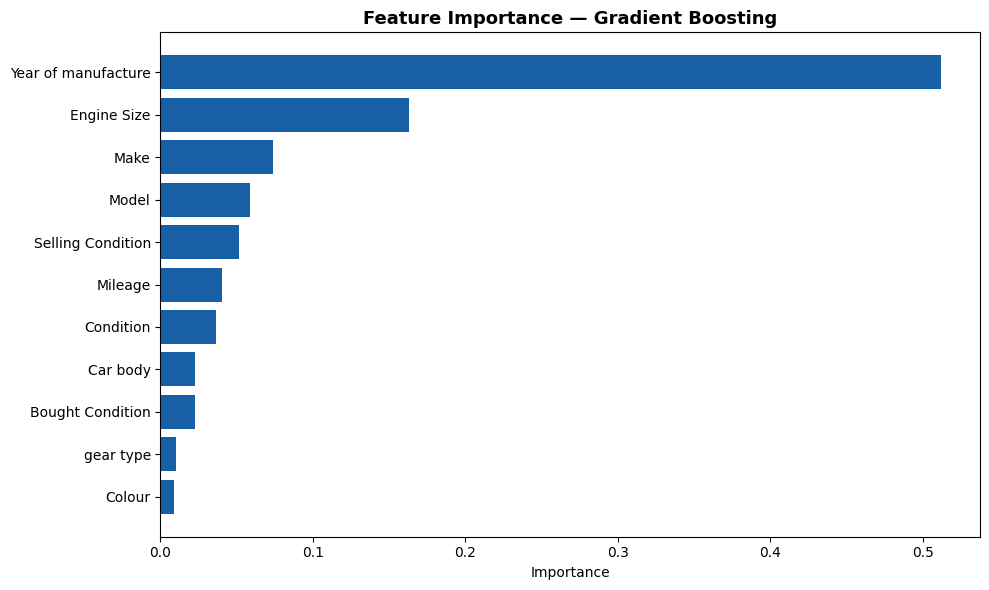

In [ ]:
# Feature Importance
fi = pd.DataFrame({
    'Feature'   : xn.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(fi.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(fi['Feature'][::-1], fi['Importance'][::-1], color='#185FA5')
plt.title('Feature Importance — Gradient Boosting', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
new = (ytestn)
new2 = (testpredn)

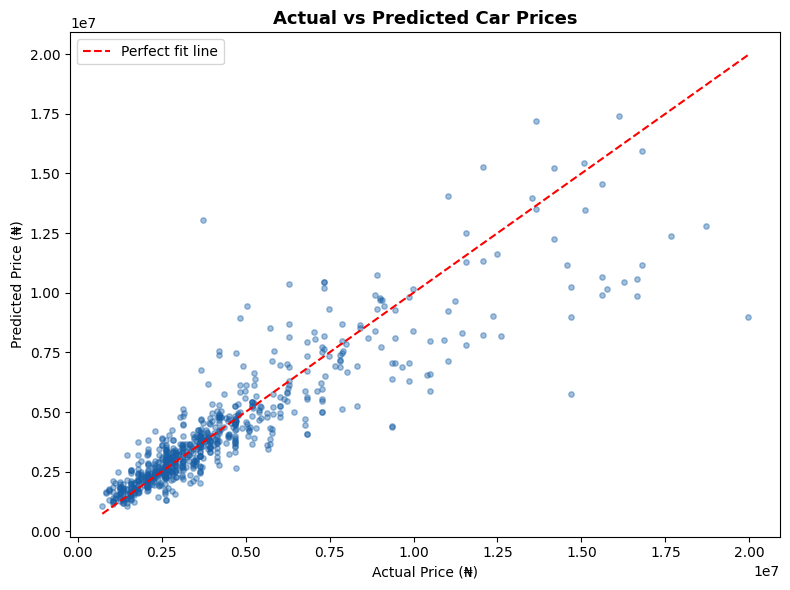

In [ ]:
# Plottinr the predicted prices vs the actual prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, testpredn, alpha=0.4, color='#185FA5', s=15)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         color='red', linewidth=1.5, linestyle='--', label='Perfect fit line')
plt.xlabel('Actual Price (₦)', fontsize=10)
plt.ylabel('Predicted Price (₦)', fontsize=10)
plt.title('Actual vs Predicted Car Prices', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

From the plot we can see that the dot cluster moved up meaning the model generalizes well.

### Do well to check the `app.py` file for the streamlit application. Please follow and drop a star Thank You